# Loan Limit Term Extension — Optimisation System

## Overview
This notebook implements a **term extension optimisation system** for 30,000 consumer lending customers.

A "loan limit increase" here means **extending the borrowing term by a variable number of days** — not increasing the credit dollar amount. The model determines which customers should receive an extension to maximise portfolio profitability while keeping default risk within regulatory constraints.

### Pipeline
| Step | Component | Method |
|------|-----------|--------|
| 1 | Data Loading & Preprocessing | pandas, StandardScaler |
| 2 | Credit State Classification | Ordinal ranking (Borda count) + K-Means |
| 3 | Macro Data Enrichment | FRED API (cached), World Bank |
| 4 | Markov Chain Analyser | 4-state transition matrix |
| 5 | Demand Forecaster | Stochastic uptake model |
| 6 | Term Extension Simulator | Monte Carlo — 3 outcomes × variable term |
| 7 | LP Optimisation | Binary grant/deny — scipy HiGHS |
| 8 | Solution Validation | 40 correctness properties |
| 9 | Sensitivity Analysis | Optimistic / Baseline / Adverse |
| 10 | Results & Visualisation | 12 charts, CSV export |

### Key model novelties vs a simple credit-limit model
- **Variable term T_i**: drawn from a state-specific lognormal distribution
- **Hazard-rate default**: P(default | T) = 1 − exp(−λ·T/365) — proper continuous-time model
- **Three outcomes**: early repayment / on-time / default — each with distinct cash-flow impact
- **Binary LP**: x_i ∈ {0,1} (relaxed to [0,1] for the LP) — grant or deny, no fractional extension

## 0. Imports & Configuration

In [1]:
# ── Standard library ─────────────────────────────────────────────────────────
import os, json, math, time, warnings
from pathlib import Path
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Any, Optional

warnings.filterwarnings('ignore')

# ── Core ─────────────────────────────────────────────────────────────────────
import numpy  as np
import pandas as pd
from scipy.optimize    import linprog
from scipy.stats       import lognorm
from sklearn.cluster   import KMeans
from sklearn.preprocessing import StandardScaler

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'figure.figsize': (10, 5)})

# ── Macro API ─────────────────────────────────────────────────────────────────
try:
    from fredapi import Fred
    FRED_AVAILABLE = True
except ImportError:
    FRED_AVAILABLE = False

import requests

print("All imports OK")
print(f"  FRED API available: {FRED_AVAILABLE}")


All imports OK
  FRED API available: True


In [2]:
# ── Configuration (override via environment variables) ─────────────────────────
DATA_FILE               = Path(os.getenv('DATA_FILE',          'loan_limit_increases.csv'))
RESULTS_FILE            = os.getenv('RESULTS_FILE',            'term_extension_results.csv')
CACHE_DIR               = Path('cache'); CACHE_DIR.mkdir(exist_ok=True)

NPV_DISCOUNT_RATE       = float(os.getenv('NPV_DISCOUNT_RATE',       '0.19'))
SIMULATION_ITERATIONS   = int(  os.getenv('SIMULATION_ITERATIONS',   '3500'))
MAX_PORTFOLIO_DEFAULT_RISK = float(os.getenv('MAX_PORTFOLIO_DEFAULT_RISK', '0.05'))
MAX_TOTAL_EXPOSURE      = float(os.getenv('MAX_TOTAL_EXPOSURE',      '500_000_000'))
MIN_DAYS_SINCE_LOAN     = int(  os.getenv('MIN_DAYS_SINCE_LOAN',     '60'))
LGD                     = float(os.getenv('LGD',                     '0.60'))
PROFIT_PER_EXTENSION    = float(os.getenv('PROFIT_PER_EXTENSION',    '40.0'))
BATCH_SIZE              = int(  os.getenv('BATCH_SIZE',               '5000'))
HORIZON_DAYS            = int(  os.getenv('HORIZON_DAYS',             '365'))

CREDIT_STATES = ['Excellent', 'Good', 'Fair', 'Poor']

# ── Term extension parameters by credit state ──────────────────────────────────
# mean_days  : expected extension length (customer-specific factors shift this)
# std_days   : variability in extension length
# lambda_ann : annual default hazard rate (aligned with FDIC charge-off norms by tier)
# p_early    : probability of early repayment before term expires
TERM_PARAMS = {
    'Excellent': {'mean_days': 90, 'std_days': 12, 'lambda_ann': 0.015, 'p_early': 0.25},
    'Good':      {'mean_days': 75, 'std_days': 15, 'lambda_ann': 0.040, 'p_early': 0.20},
    'Fair':      {'mean_days': 60, 'std_days': 18, 'lambda_ann': 0.100, 'p_early': 0.12},
    'Poor':      {'mean_days': 45, 'std_days': 20, 'lambda_ann': 0.220, 'p_early': 0.05},
}

# ── Macro scenarios ────────────────────────────────────────────────────────────
MACRO_SCENARIOS = {
    'optimistic': {'gdp_growth': 3.5, 'unemployment': 3.5, 'fed_rate': 4.0, 'cpi': 2.5},
    'baseline':   {'gdp_growth': 2.5, 'unemployment': 4.0, 'fed_rate': 5.0, 'cpi': 3.5},
    'adverse':    {'gdp_growth': 0.5, 'unemployment': 5.5, 'fed_rate': 6.0, 'cpi': 5.0},
}

print(f"  Discount rate        : {NPV_DISCOUNT_RATE:.0%}")
print(f"  Simulation iterations: {SIMULATION_ITERATIONS:,}")
print(f"  Max portfolio risk   : {MAX_PORTFOLIO_DEFAULT_RISK:.0%}")
print(f"  Max total exposure   : ${MAX_TOTAL_EXPOSURE:,.0f}")
print(f"  Profit per extension : ${PROFIT_PER_EXTENSION:.0f}")
print(f"  LGD                  : {LGD:.0%}")

  Discount rate        : 19%
  Simulation iterations: 3,500
  Max portfolio risk   : 5%
  Max total exposure   : $500,000,000
  Profit per extension : $40
  LGD                  : 60%


## 1. Data Loading & Preprocessing

In [3]:
def load_and_preprocess_data(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    df = df.rename(columns={
        'Customer ID':             'customer_id',
        'Initial Loan ($)':        'initial_loan',
        'Days Since Last Loan':    'days_since_last_loan',
        'On-time Payments (%)':    'on_time_payments_pct',
        'No. of Increases in 2023':'num_increases_2023',
        'Total Profit Contribution ($)': 'total_profit_contribution',
    })
    assert len(df) == 30_000, f"Expected 30,000 rows, got {len(df)}"
    assert df.isnull().sum().sum() == 0, "Missing values found"

    # Eligibility: >= 60 days since last disbursement + on-time payments
    df['eligible'] = (df['days_since_last_loan'] >= MIN_DAYS_SINCE_LOAN).astype(int)
    df['utilization_rate'] = np.clip(
        1.0 - df['days_since_last_loan'].clip(0, 365) / 365.0, 0.05, 0.95
    )

    # Normalise for credit scoring
    scaler = StandardScaler()
    num_cols = ['initial_loan','days_since_last_loan','on_time_payments_pct',
                'num_increases_2023','total_profit_contribution']
    df_scaled = df.copy()
    df_scaled[num_cols] = scaler.fit_transform(df[num_cols])

    print(f"Loaded {len(df):,} customers")
    print(f"  Eligible (days >= {MIN_DAYS_SINCE_LOAN}): {df['eligible'].sum():,} ({df['eligible'].mean():.1%})")
    print(f"  Loan range: ${df['initial_loan'].min():,.0f} – ${df['initial_loan'].max():,.0f}")
    print(df[['initial_loan','days_since_last_loan','on_time_payments_pct',
              'num_increases_2023']].describe().round(2))
    return df

df_raw = load_and_preprocess_data(DATA_FILE)
df = df_raw.copy()

Loaded 30,000 customers
  Eligible (days >= 60): 25,068 (83.6%)
  Loan range: $500 – $4,999
       initial_loan  days_since_last_loan  on_time_payments_pct  \
count      30000.00              30000.00              30000.00   
mean        2752.53                181.48                 90.02   
std         1293.03                105.07                  5.75   
min          500.00                  0.00                 80.00   
25%         1630.00                 90.00                 85.08   
50%         2761.00                182.00                 90.05   
75%         3866.00                272.00                 95.01   
max         4999.00                364.00                100.00   

       num_increases_2023  
count            30000.00  
mean                 2.24  
std                  2.08  
min                  0.00  
25%                  0.00  
50%                  3.00  
75%                  4.00  
max                  5.00  


## 2. Credit State Classification

In [4]:
def classify_credit_states(df: pd.DataFrame) -> pd.DataFrame:
    """
    Two-step classification: Borda-count composite → K-Means on RISK RANK.

    Step 1: Ordinal Borda-count credit_score (FICO-aligned weights):
      35% payment history | 30% credit discipline | 20% recency | 15% value

    Step 2: risk_rank = 1 − credit_score  (0 = safest, 1 = riskiest)
            K-Means (k=4) on risk_rank → data-driven tier boundaries.
            Lowest centroid = Excellent, highest = Poor.

    Using risk_rank (not credit_score) for clustering aligns the K-Means axis
    with the quantity being managed (default risk), not its inverse.
    A comparison of percentile vs K-Means boundaries is printed for audit.
    """
    df = df.copy()
    n  = len(df)

    # ── Step 1: Borda-count credit score ──────────────────────────────────────
    r_pay  = df['on_time_payments_pct'].rank(pct=True)
    r_disc = (1 - df['num_increases_2023'].rank(pct=True))
    r_rec  = (1 - df['days_since_last_loan'].rank(pct=True))
    r_val  = df['total_profit_contribution'].rank(pct=True)
    df['credit_score'] = r_pay * 0.35 + r_disc * 0.30 + r_rec * 0.20 + r_val * 0.15

    # ── Step 2: risk_rank = 1 − credit_score ──────────────────────────────────
    df['risk_rank'] = 1.0 - df['credit_score']

    # ── Percentile thresholds (25/50/75 on risk_rank) — comparison baseline ──
    q25, q50, q75 = df['risk_rank'].quantile([0.25, 0.50, 0.75]).values

    def pct_state(rr):
        if rr <= q25: return 'Excellent'
        if rr <= q50: return 'Good'
        if rr <= q75: return 'Fair'
        return 'Poor'
    states_pct = df['risk_rank'].apply(pct_state)

    # ── K-Means on risk_rank ──────────────────────────────────────────────────
    km = KMeans(n_clusters=4, random_state=42, n_init=20)
    km.fit(df[['risk_rank']])
    centroids = km.cluster_centers_.flatten()
    # Ascending centroid order → Excellent (safest) to Poor (riskiest)
    order     = np.argsort(centroids)
    label_map = {old: CREDIT_STATES[new] for new, old in enumerate(order)}
    states_km = pd.Series([label_map[c] for c in km.labels_], index=df.index)

    # ── Comparison table ──────────────────────────────────────────────────────
    print("=" * 68)
    print("  CLASSIFICATION: Percentile (25/50/75) vs K-Means on risk_rank")
    print("=" * 68)
    print(f"  {'State':<12} {'Percentile':>14} {'K-Means':>14} {'Δ':>8}")
    print(f"  {'-'*52}")
    for state in CREDIT_STATES:
        p = (states_pct == state).sum()
        k = (states_km  == state).sum()
        print(f"  {state:<12} {p:>7,} ({100*p/n:4.1f}%)  {k:>7,} ({100*k/n:4.1f}%)  "
              f"{'↑' if k>p else '↓' if k<p else '='}{abs(k-p):>5,}")
    diff = (states_pct != states_km).sum()
    print(f"  Customers re-assigned by K-Means: {diff:,} / {n:,} ({100*diff/n:.1f}%)")
    print("=" * 68)
    print("  → K-Means adopted as primary (data-driven boundaries on risk axis)")

    # ── Adopt K-Means ─────────────────────────────────────────────────────────
    df['credit_state'] = states_km.values

    # ── Within-state default risk: base × (0.5 + within_state_pctile) ─────────
    base = {'Excellent': 0.010, 'Good': 0.030, 'Fair': 0.080, 'Poor': 0.200}
    dr   = np.zeros(n)
    for state in CREDIT_STATES:
        mask = df['credit_state'] == state
        within = df.loc[mask, 'risk_rank'].rank(pct=True)
        dr[mask.values] = np.clip(base[state] * (0.5 + within), 0.001, 0.99)
    df['default_risk']    = dr
    df['high_risk_flag']  = (dr > 0.15).astype(int)
    df['risk_model']      = 'ordinal_risk_rank_kmeans'

    print("\nCredit state distribution (K-Means on risk_rank):")
    print(df['credit_state'].value_counts().reindex(CREDIT_STATES))
    print(f"\nDefault risk: mean={dr.mean():.3f}  min={dr.min():.3f}  max={dr.max():.3f}")
    return df

df = classify_credit_states(df)


  CLASSIFICATION: Percentile (25/50/75) vs K-Means on risk_rank
  State            Percentile        K-Means        Δ
  ----------------------------------------------------
  Excellent      7,500 (25.0%)    6,206 (20.7%)  ↓1,294
  Good           7,500 (25.0%)    9,267 (30.9%)  ↑1,767
  Fair           7,500 (25.0%)    9,089 (30.3%)  ↑1,589
  Poor           7,500 (25.0%)    5,438 (18.1%)  ↓2,062
  Customers re-assigned by K-Means: 3,829 / 30,000 (12.8%)
  → K-Means adopted as primary (data-driven boundaries on risk axis)

Credit state distribution (K-Means on risk_rank):
credit_state
Excellent    6206
Good         9267
Fair         9089
Poor         5438
Name: count, dtype: int64

Default risk: mean=0.072  min=0.005  max=0.300


## 3. Macro Data Enrichment

In [5]:
# ── FRED API Macro Data Fetching ─────────────────────────────────────────────
# Set your FRED API key as: export FRED_API_KEY="your_key_here"
# Get a free key at: https://fred.stlouisfed.org/docs/api/api_key.html
# If no key is set the function falls back to cached baseline defaults.

MACRO_CACHE_FILE = CACHE_DIR / 'macro_data_2023.json'


def fetch_macro_data(year: int = 2023) -> Dict[str, float]:
    """
    Fetch macroeconomic indicators from FRED API with caching and retry logic.

    Series fetched:
      GDPC1    — Real GDP (quarterly, pct change annualised)
      UNRATE   — Unemployment rate (monthly avg)
      FEDFUNDS — Federal Funds Rate (monthly avg)
      CPIAUCSL — CPI All Urban (YoY pct change)

    Returns dict with keys: gdp_growth, unemployment, fed_rate, cpi, inflation.
    Falls back to cached data, then to baseline defaults on API failure.
    """
    # 1. Try disk cache first
    if MACRO_CACHE_FILE.exists():
        with open(MACRO_CACHE_FILE) as f:
            cached = json.load(f)
        print(f"  Macro data loaded from cache ({MACRO_CACHE_FILE})")
        return cached

    # 2. Attempt FRED API (requires FRED_API_KEY env var)
    api_key = os.getenv('FRED_API_KEY', '')
    if FRED_AVAILABLE and api_key:
        for attempt in range(3):
            try:
                fred   = Fred(api_key=api_key)
                start  = f'{year}-01-01'
                end    = f'{year}-12-31'

                gdp   = fred.get_series('GDPC1',    start, end).pct_change().mean() * 100
                unemp = fred.get_series('UNRATE',   start, end).mean()
                fed   = fred.get_series('FEDFUNDS', start, end).mean()
                cpi   = fred.get_series('CPIAUCSL', start, end).pct_change(12).iloc[-1] * 100

                data = {
                    'gdp_growth':   round(float(gdp),   2),
                    'unemployment': round(float(unemp),  2),
                    'fed_rate':     round(float(fed),    2),
                    'cpi':          round(float(cpi),    2),
                    'inflation':    round(float(cpi),    2),
                }
                with open(MACRO_CACHE_FILE, 'w') as f:
                    json.dump(data, f, indent=2)
                print(f"  FRED API fetch successful (attempt {attempt + 1})")
                return data

            except Exception as e:
                wait = 2 ** attempt
                print(f"  FRED API attempt {attempt + 1} failed: {e}. Retrying in {wait}s …")
                time.sleep(wait)
    else:
        if not api_key:
            print("  FRED_API_KEY not set — skipping live fetch")
        if not FRED_AVAILABLE:
            print("  fredapi package not installed — run: pip install fredapi")

    # 3. Fall back to hardcoded baseline defaults (2023 actuals)
    print("  WARNING: Using baseline macro defaults")
    data = {
        'gdp_growth':   2.5,
        'unemployment': 4.0,
        'fed_rate':     5.0,
        'cpi':          3.5,
        'inflation':    3.5,
    }
    with open(MACRO_CACHE_FILE, 'w') as f:
        json.dump(data, f, indent=2)
    return data


def fetch_macro_scenarios() -> Dict[str, Dict[str, float]]:
    """
    Return macro data for all three scenarios.
    Scales the fetched/cached baseline proportionally using MACRO_SCENARIOS ratios.
    This ensures live FRED data flows into scenario analysis automatically.
    """
    base = fetch_macro_data()
    base_ref  = MACRO_SCENARIOS['baseline']   # reference ratios
    opt_ref   = MACRO_SCENARIOS['optimistic']
    adv_ref   = MACRO_SCENARIOS['adverse']

    def scale(ref_scenario):
        return {
            k: round(base[k] * ref_scenario[k] / base_ref[k], 3)
            if base_ref.get(k, 0) != 0 else base[k]
            for k in base
        }

    return {
        'optimistic': scale(opt_ref),
        'baseline':   dict(base),
        'adverse':    scale(adv_ref),
    }


def enrich_with_macro(df: pd.DataFrame, macro: Dict[str, float]) -> pd.DataFrame:
    """
    Adjust per-customer default risk and term parameters using macro conditions.

    Adjustment rules (calibrated to historical recession data):
      +1 pp unemployment above baseline (4%)  → +1 pp annual hazard rate
      +1 pp fed funds rate above baseline (5%) → +0.5 pp annual hazard rate
      +1 pp GDP growth above baseline (2.5%)   → +10 day extension term offered
    """
    df = df.copy()

    unemp_adj    = (macro.get('unemployment', 4.0) - 4.0) * 0.01
    rate_adj     = (macro.get('fed_rate',     5.0) - 5.0) * 0.005
    macro_risk_adj = 1.0 + unemp_adj + rate_adj

    df['default_risk'] = np.clip(df['default_risk'] * macro_risk_adj, 0.001, 0.99)

    gdp_adj = (macro.get('gdp_growth', 2.5) - 2.5) / 100.0
    df['term_adj_days'] = gdp_adj * 10

    # Store macro indicators as columns for downstream use
    df['macro_gdp_growth']   = macro.get('gdp_growth',   2.5)
    df['macro_unemployment'] = macro.get('unemployment', 4.0)
    df['macro_fed_rate']     = macro.get('fed_rate',     5.0)
    df['macro_cpi']          = macro.get('cpi',          3.5)

    print(f"  Macro risk multiplier : ×{macro_risk_adj:.3f}")
    print(f"  Term day adjustment   : {gdp_adj * 10:+.1f} days")
    return df


# ── Fetch and enrich ──────────────────────────────────────────────────────────
macro_data     = fetch_macro_data()
macro_scenarios = fetch_macro_scenarios()

print("\nMacroeconomic Indicators (Baseline):")
for k, v in macro_data.items():
    print(f"  {k:<20}: {v:.2f}")

df = enrich_with_macro(df, macro_data)
print(f"\nMacro enrichment complete  →  {df.shape[0]:,} customers enriched")
print(f"  Adjusted default risk: mean={df['default_risk'].mean():.4f}")


  Macro data loaded from cache (cache/macro_data_2023.json)
  Macro data loaded from cache (cache/macro_data_2023.json)

Macroeconomic Indicators (Baseline):
  gdp_growth          : 2.50
  unemployment        : 4.00
  fed_rate            : 5.00
  cpi                 : 3.50
  inflation           : 3.50
  Macro risk multiplier : ×1.000
  Term day adjustment   : +0.0 days

Macro enrichment complete  →  30,000 customers enriched
  Adjusted default risk: mean=0.0718


## 4. Markov Chain — Credit State Transitions

In [6]:
@dataclass
class TransitionMatrix:
    matrix:       np.ndarray
    state_labels: List[str]
    steady_state: np.ndarray
    observation_period_days: int = 90

def compute_steady_state(T: np.ndarray) -> np.ndarray:
    evals, evecs = np.linalg.eig(T.T)
    idx = np.argmin(np.abs(evals - 1.0))
    ss = np.abs(evecs[:, idx].real)
    return ss / ss.sum()

def build_transition_matrix(df: pd.DataFrame) -> TransitionMatrix:
    """
    Estimate 4×4 transition matrix from payment behaviour.

    Logic: customers with high on-time payment rate trend toward better states;
    high num_increases (credit-seeking) and low profit trend toward worse states.
    """
    n = len(CREDIT_STATES)
    # Base transition (near-identity with small off-diagonal flow)
    T = np.array([
        [0.88, 0.09, 0.02, 0.01],   # Excellent → ...
        [0.08, 0.82, 0.08, 0.02],   # Good      → ...
        [0.02, 0.10, 0.78, 0.10],   # Fair      → ...
        [0.01, 0.05, 0.18, 0.76],   # Poor      → ...
    ], dtype=np.float64)

    # Adjust off-diagonals using portfolio payment behaviour
    avg_ontime = df['on_time_payments_pct'].mean() / 100.0
    improvement_factor = (avg_ontime - 0.85) * 2.0   # > 0 if above 85%

    for i in range(n - 1):
        shift = np.clip(improvement_factor * 0.02, -0.05, 0.05)
        T[i, i]     = np.clip(T[i, i]     + shift, 0.01, 0.99)
        T[i, i + 1] = np.clip(T[i, i + 1] - shift, 0.01, 0.99)

    # Row-normalise
    T = T / T.sum(axis=1, keepdims=True)
    ss = compute_steady_state(T)

    tm = TransitionMatrix(matrix=T, state_labels=CREDIT_STATES,
                          steady_state=ss, observation_period_days=90)
    print("Transition matrix:")
    print(pd.DataFrame(T, index=CREDIT_STATES, columns=CREDIT_STATES).round(4).to_string())
    print(f"\nSteady-state probabilities:")
    for s, p in zip(CREDIT_STATES, ss):
        print(f"  {s:<12}: {p:.3f} ({p*100:.1f}%)")
    return tm

transition_matrix = build_transition_matrix(df)

Transition matrix:
           Excellent   Good   Fair   Poor
Excellent      0.882  0.088  0.020  0.010
Good           0.080  0.822  0.078  0.020
Fair           0.020  0.100  0.782  0.098
Poor           0.010  0.050  0.180  0.760

Steady-state probabilities:
  Excellent   : 0.274 (27.4%)
  Good        : 0.322 (32.2%)
  Fair        : 0.259 (25.9%)
  Poor        : 0.144 (14.4%)


## 5. Demand Forecasting — Uptake Probability

In [7]:
# ── GBM Uptake Forecast ──────────────────────────────────────────────────────
#
# Uptake probability = P(customer accepts the term extension offer)
#
# Modelled using Geometric Brownian Motion (GBM), matching the claude-branch
# utilization forecasting approach:
#
#   U_T = μ_i · exp(−½σ²·dt + σ·dW)      dW ~ N(0, sqrt(dt))
#
# where μ_i = state base rate + macro drift + individual profit adjustment.
# GBM produces lognormal terminal values: positive, right-skewed, and bounded
# by clipping to [0.01, 0.99]. Volatility (σ) is higher for riskier states
# because their behaviour is less predictable.
#
# Scenario adjustments mirror the claude branch:
#   Optimistic: drift_adj = +0.02, vol_scale = 0.80  (higher uptake, less noise)
#   Baseline:   drift_adj =  0.00, vol_scale = 1.00
#   Adverse:    drift_adj = −0.03, vol_scale = 1.30  (lower uptake, more noise)

UPTAKE_PARAMS = {
    # state      mu     sigma   (mu = base uptake rate; sigma = GBM volatility)
    'Excellent': {'mu': 0.80, 'sigma': 0.10},
    'Good':      {'mu': 0.70, 'sigma': 0.12},
    'Fair':      {'mu': 0.55, 'sigma': 0.16},
    'Poor':      {'mu': 0.35, 'sigma': 0.20},
}

def forecast_uptake(
    df: pd.DataFrame,
    macro: Dict[str, float],
    n_scenarios: int = SIMULATION_ITERATIONS,
    scenario: str = 'baseline',
) -> pd.DataFrame:
    """
    GBM stochastic uptake model: P(customer accepts term extension offer).

    Uses Geometric Brownian Motion terminal values so uptake paths are
    lognormally distributed — positive, right-skewed, consistent with the
    claude-branch utilization forecasting methodology.

    Factors:
      - Credit state:    state-specific GBM mu (base rate) and sigma (volatility)
      - Macro scenario:  GDP/unemployment shift drift and volatility scaling
      - Individual:      profit-history rank adds ±5pp personalised drift
    """
    df = df.copy()
    rng = np.random.default_rng(42)

    # Scenario adjustments (mirrors claude branch forecast_utilization)
    scenario_adj = {
        'optimistic': {'drift_adj': +0.02, 'vol_scale': 0.80},
        'baseline':   {'drift_adj':  0.00, 'vol_scale': 1.00},
        'adverse':    {'drift_adj': -0.03, 'vol_scale': 1.30},
    }.get(scenario, {'drift_adj': 0.0, 'vol_scale': 1.0})

    # Additional macro adjustment from live macro data
    gdp_adj   = (macro.get('gdp_growth',   2.5) - 2.5) * 0.02
    unemp_adj = -(macro.get('unemployment', 4.0) - 4.0) * 0.03
    macro_drift = gdp_adj + unemp_adj + scenario_adj['drift_adj']
    vol_scale   = scenario_adj['vol_scale']

    uptake_rates = np.zeros(len(df))
    uptake_std   = np.zeros(len(df))

    dt = 1.0  # normalised time horizon (uptake is a point-in-time decision)

    for state in CREDIT_STATES:
        mask = df['credit_state'] == state
        if not mask.any():
            continue
        nc = mask.sum()

        params = UPTAKE_PARAMS[state]
        sigma  = params['sigma'] * vol_scale

        # Individual drift: profit rank shifts mu ±5pp around state base
        profit_rank = df.loc[mask, 'total_profit_contribution'].rank(pct=True)
        mu_i = np.clip(params['mu'] + macro_drift + profit_rank.values * 0.10 - 0.05,
                       0.05, 0.95)

        # GBM terminal value per customer per scenario
        # Shape: (n_scenarios, nc)
        dW     = rng.normal(0.0, np.sqrt(dt), (n_scenarios, nc))
        draws  = np.clip(
            mu_i[np.newaxis, :] * np.exp(-0.5 * sigma**2 * dt + sigma * dW),
            0.01, 0.99
        )

        cohort_mean = draws.mean(axis=0)   # per-customer mean across scenarios
        cohort_std  = draws.std(axis=0)

        uptake_rates[mask.values] = cohort_mean
        uptake_std  [mask.values] = cohort_std

    df['uptake_probability'] = np.clip(uptake_rates, 0.01, 0.99)
    df['uptake_std']         = uptake_std
    df['forecast_scenario']  = scenario

    print(f"GBM uptake forecast  (macro_drift={macro_drift:+.3f}, vol_scale={vol_scale:.2f}):")
    for state in CREDIT_STATES:
        mask = df['credit_state'] == state
        u = df.loc[mask, 'uptake_probability']
        print(f"  {state:<10}: mean={u.mean():.3f}  std={u.std():.3f}  "
              f"[{u.min():.3f}, {u.max():.3f}]")
    return df

df = forecast_uptake(df, macro_data, scenario='baseline')

GBM uptake forecast  (macro_drift=+0.000, vol_scale=1.00):
  Excellent : mean=0.799  std=0.024  [0.777, 0.848]
  Good      : mean=0.700  std=0.027  [0.668, 0.746]
  Fair      : mean=0.550  std=0.028  [0.515, 0.595]
  Poor      : mean=0.350  std=0.028  [0.307, 0.387]


## 6. Term Extension Monte Carlo Simulation

In [8]:
# ── Vectorised Monte Carlo — Term Extension Simulation ───────────────────────
#
# Processes all customers in a credit state simultaneously as (nc, n_iter)
# matrix operations — no per-customer Python loops (10-20× faster than before).
#
# Three outcomes per scenario:
#   Early repay : u1 < p_early                                   → no loss
#   Default     : (not early) AND (u2 < 1 − exp(−λ × T/365))    → L × LGD
#   On-time     : residual                                        → no loss
#
# NPV:
#   Revenue = $40 × annuity_factor(T, r)     [mid-period annuity]
#   Loss    = L × LGD × 1(default) × exp(−r × T/730)  [mid-term discount]

# Precompute lognormal parameters for each state
def _ln_params(mu_d, std_d):
    sigma_ln = math.sqrt(math.log(1 + (std_d / mu_d) ** 2))
    mu_ln    = math.log(mu_d) - sigma_ln ** 2 / 2.0
    return mu_ln, sigma_ln

_LN = {state: _ln_params(p['mean_days'], p['std_days'])
       for state, p in TERM_PARAMS.items()}

def simulate_term_extensions(
    df: pd.DataFrame,
    n_iterations: int = SIMULATION_ITERATIONS,
    discount_rate: float = NPV_DISCOUNT_RATE,
    batch_size:    int   = BATCH_SIZE,
) -> pd.DataFrame:
    """
    Fully vectorised Monte Carlo: processes all customers per batch as
    (nc_batch, n_iterations) matrices — no inner Python loop over customers.
    """
    t0  = time.time()
    n   = len(df)
    rng = np.random.default_rng(42)
    print(f"Simulating {n:,} customers | {n_iterations:,} iterations each (vectorised)")

    revenues    = np.zeros(n, np.float64)
    losses      = np.zeros(n, np.float64)
    exp_terms   = np.zeros(n, np.float64)
    p_def_sim   = np.zeros(n, np.float64)
    p_early_sim = np.zeros(n, np.float64)

    state_arr    = df['credit_state'].values
    loan_arr     = df['initial_loan'].values.astype(np.float32)
    term_adj_arr = (df['term_adj_days'].values.astype(np.float32)
                    if 'term_adj_days' in df.columns
                    else np.zeros(n, np.float32))

    # Build per-customer parameter arrays (vectorised lookup)
    mu_ln_arr    = np.array([_LN[s][0] for s in state_arr], dtype=np.float32)
    sigma_ln_arr = np.array([_LN[s][1] for s in state_arr], dtype=np.float32)
    lam_arr      = np.array([TERM_PARAMS[s]['lambda_ann'] for s in state_arr], dtype=np.float32)
    p_early_arr  = np.array([TERM_PARAMS[s]['p_early']    for s in state_arr], dtype=np.float32)

    n_batches = math.ceil(n / batch_size)
    for b in range(n_batches):
        s, e = b * batch_size, min((b + 1) * batch_size, n)
        nc   = e - s

        mu_ln    = mu_ln_arr   [s:e, np.newaxis]   # (nc, 1)
        sigma_ln = sigma_ln_arr[s:e, np.newaxis]
        lam      = lam_arr     [s:e, np.newaxis]
        p_early  = p_early_arr [s:e, np.newaxis]
        L        = loan_arr    [s:e, np.newaxis]
        t_adj    = term_adj_arr[s:e, np.newaxis]

        # Draw all terms: (nc, n_iterations)
        Z = rng.standard_normal((nc, n_iterations)).astype(np.float32)
        T = np.clip(np.exp(mu_ln + sigma_ln * Z) + t_adj, 30.0, 180.0)

        # Hazard-rate default probability per scenario
        p_def_T = (1.0 - np.exp(-lam * T / 365.0)).astype(np.float32)

        # Three-outcome draws
        u1 = rng.random((nc, n_iterations), dtype=np.float32)
        u2 = rng.random((nc, n_iterations), dtype=np.float32)
        is_early   = u1 < p_early                           # (nc, n_iter)
        is_default = (~is_early) & (u2 < p_def_T)

        # NPV
        rT = discount_rate * T / 365.0
        npv_factor   = ((1.0 - np.exp(-rT)) / (rT + 1e-10)).astype(np.float32)
        npv_loss_fac = np.exp(-discount_rate * T / 730.0).astype(np.float32)

        rev_mat  = PROFIT_PER_EXTENSION * npv_factor
        loss_mat = L * LGD * is_default.astype(np.float32) * npv_loss_fac

        revenues   [s:e] = rev_mat.mean(axis=1)
        losses     [s:e] = loss_mat.mean(axis=1)
        exp_terms  [s:e] = T.mean(axis=1)
        p_def_sim  [s:e] = is_default.astype(np.float32).mean(axis=1)
        p_early_sim[s:e] = is_early.astype(np.float32).mean(axis=1)

        if n_batches > 1:
            print(f"  Batch {b+1}/{n_batches} done")

    df = df.copy()
    df['expected_revenue']    = revenues
    df['expected_loss']       = losses
    df['profitability_score'] = revenues - losses
    df['expected_term_days']  = exp_terms
    df['p_default_sim']       = p_def_sim
    df['p_early_sim']         = p_early_sim

    print(f"\nSimulation completed in {time.time()-t0:.1f}s")
    print(f"  Expected term (mean): {exp_terms.mean():.1f} days")
    print(f"  P(default) (mean)   : {p_def_sim.mean():.4f}")
    print(f"  P(early)   (mean)   : {p_early_sim.mean():.4f}")
    print(f"  Expected revenue    : ${revenues.mean():.2f}")
    print(f"  Expected loss       : ${losses.mean():.2f}")
    print(f"  Profitability score : ${(revenues - losses).mean():.2f}")
    return df

df = simulate_term_extensions(df)


Simulating 30,000 customers | 3,500 iterations each (vectorised)


  Batch 1/6 done


  Batch 2/6 done


  Batch 3/6 done


  Batch 4/6 done


  Batch 5/6 done


  Batch 6/6 done

Simulation completed in 4.5s
  Expected term (mean): 68.4 days
  P(default) (mean)   : 0.0117
  P(early)   (mean)   : 0.1589
  Expected revenue    : $39.30
  Expected loss       : $18.95
  Profitability score : $20.35


## 7. Constraint Definition

In [9]:
def create_constraints() -> Dict[str, float]:
    return {
        'max_portfolio_default_risk': MAX_PORTFOLIO_DEFAULT_RISK,
        'max_total_exposure':         MAX_TOTAL_EXPOSURE,
    }

constraints = create_constraints()
print("Constraint set:")
for k, v in constraints.items():
    print(f"  {k}: {v:,.4f}")

Constraint set:
  max_portfolio_default_risk: 0.0500
  max_total_exposure: 500,000,000.0000


## 8. LP Optimisation — Binary Term Extension Decisions

In [10]:
# ── Mathematical formulation ────────────────────────────────────────────────────
#
# Decision variables:
#   x_i ∈ [0, 1]  — whether customer i receives a term extension
#   (LP relaxation of binary {0,1}; corner solutions dominate in practice)
#
# Objective (maximise expected NPV profit):
#   Maximise  Σ_i  π_i · x_i
#   where  π_i = expected_revenue_i − expected_loss_i
#              = E[40 · npv(T_i)] − E[L_i · LGD · 1(default_i) · npv_loss(T_i)]
#
# Constraints:
#   (1) Weighted default risk on extended exposure ≤ max_portfolio_default_risk:
#       Σ_i (p_default_i − max_risk) · L_i · x_i  ≤  0
#
#   (2) Total extended exposure ≤ max_total_exposure:
#       Σ_i  L_i · x_i  ≤  max_total_exposure − Σ_i L_i
#
#   (3) Eligibility:  x_i = 0  if  days_since_last_loan < 60  (bound collapse)
#
#   (4) Box bounds:   x_i ∈ [0, 1]

def _greedy_fallback(df, constraints, profit_scores):
    """Greedy grant by profitability when LP solver fails."""
    x = np.zeros(len(df))
    order = np.argsort(-profit_scores)
    budget = constraints['max_total_exposure'] - df['initial_loan'].sum()
    for i in order:
        if profit_scores[i] <= 0:
            break
        if x[i] == 0 and budget >= df['initial_loan'].iloc[i]:
            x[i] = 1.0
            budget -= df['initial_loan'].iloc[i]
    return x

def optimize_extensions_lp(
    df: pd.DataFrame,
    constraints: Dict[str, float],
    solver_timeout: int = 300,
) -> Tuple[pd.DataFrame, int]:
    t0  = time.time()
    n   = len(df)
    print(f"Setting up LP: {n:,} binary extension decisions...")

    # ── Objective ───────────────────────────────────────────────────────────────
    # Uptake-weighted objective: expected profit only realised if customer accepts
    # profit × P(accept) = effective expected value of granting the extension
    profit_scores = df['profitability_score'].values * df['uptake_probability'].values
    c_obj = -profit_scores   # negate → minimisation

    # ── Bounds: x_i ∈ [0,1]; ineligible customers clamped to [0,0] ─────────────
    ub = np.ones(n, dtype=np.float64)
    if 'eligible' in df.columns:
        ineligible_mask = df['eligible'].values == 0
        ub[ineligible_mask] = 0.0
        n_inelig = ineligible_mask.sum()
        print(f"  Eligibility filter: {n_inelig:,} customers excluded (days_since_last_loan < {MIN_DAYS_SINCE_LOAN})")
    bounds = list(zip(np.zeros(n), ub))

    # ── Inequality constraints (A_ub @ x ≤ b_ub) ───────────────────────────────
    A_ub_rows, b_ub_vals = [], []

    # (1) Weighted default risk on extended exposure:
    #     Σ (p_def_i − max_risk) · L_i · x_i ≤ 0
    max_risk  = constraints['max_portfolio_default_risk']
    risk_coef = (df['p_default_sim'].values - max_risk) * df['initial_loan'].values
    A_ub_rows.append(risk_coef)
    b_ub_vals.append(0.0)

    # (2) Total extended exposure ≤ remaining capital budget
    total_existing = df['initial_loan'].sum()
    budget_remaining = constraints['max_total_exposure'] - total_existing
    A_ub_rows.append(df['initial_loan'].values.copy())
    b_ub_vals.append(max(budget_remaining, 0.0))

    A_ub = np.vstack(A_ub_rows)
    b_ub = np.array(b_ub_vals)

    # ── Solve ───────────────────────────────────────────────────────────────────
    print("Solving LP with HiGHS solver ...")
    result = linprog(
        c_obj, A_ub=A_ub, b_ub=b_ub, bounds=bounds,
        method='highs',
        options={'time_limit': solver_timeout, 'disp': False}
    )
    elapsed = time.time() - t0
    print(f"LP solved in {elapsed:.2f}s  |  Status: {result.message}")

    if result.success:
        x = np.clip(result.x, 0.0, 1.0)
        # Round: x > 0.5 → grant extension (LP relaxation corner solutions)
        granted = (x > 0.5).astype(float)
        status_code = 0
    else:
        print("WARNING: LP did not converge — greedy fallback")
        granted = _greedy_fallback(df, constraints, profit_scores)
        status_code = result.status

    results = pd.DataFrame({
        'customer_id':         df['customer_id'].values,
        'initial_loan':        df['initial_loan'].values,
        'credit_state':        df['credit_state'].values,
        'default_risk':        df['default_risk'].values,
        'p_default_sim':       df['p_default_sim'].values,
        'p_early_sim':         df['p_early_sim'].values,
        'expected_term_days':  df['expected_term_days'].values,
        'uptake_probability':  df.get('uptake_probability', pd.Series(np.ones(len(df)))).values,
        'profitability_score': df['profitability_score'].values,
        'expected_revenue':    df['expected_revenue'].values,
        'expected_loss':       df['expected_loss'].values,
        'extension_granted':   granted,
        'eligible':            df['eligible'].values,
    })

    n_granted = int(granted.sum())
    granted_mask = granted > 0.5
    rev_total  = results.loc[granted_mask, 'expected_revenue'].sum()
    loss_total = results.loc[granted_mask, 'expected_loss'].sum()
    exp_out    = (results.loc[granted_mask, 'initial_loan'] * granted[granted_mask]).sum()

    print(f"\nOptimisation results:")
    print(f"  Extensions granted     : {n_granted:,}  ({100*n_granted/len(df):.1f}% of portfolio)")
    print(f"  Total extended exposure: ${exp_out:>14,.0f}")
    print(f"  Expected revenue       : ${rev_total:>14,.0f}")
    print(f"  Expected credit loss   : ${loss_total:>14,.0f}")
    print(f"  Net expected profit    : ${rev_total - loss_total:>14,.0f}")
    return results, status_code

results_df, lp_status = optimize_extensions_lp(df, constraints)
print(f"\nSolver status: {lp_status} ({'Optimal' if lp_status == 0 else 'Sub-optimal'})")

Setting up LP: 30,000 binary extension decisions...
  Eligibility filter: 4,932 customers excluded (days_since_last_loan < 60)
Solving LP with HiGHS solver ...
LP solved in 0.12s  |  Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Optimisation results:
  Extensions granted     : 21,469  (71.6% of portfolio)
  Total extended exposure: $    54,743,119
  Expected revenue       : $       843,425
  Expected credit loss   : $       311,018
  Net expected profit    : $       532,407

Solver status: 0 (Optimal)


## 9. LP–Markov Feedback Loop

In [11]:
def apply_policy_to_transitions(df, granted, tm, policy_strength=0.12):
    """
    Extend granted customers have improved transition probabilities:
    receiving an extension (and making payments) shifts probability mass
    toward better credit states.
    """
    adj = tm.matrix.copy()
    n_states = len(CREDIT_STATES)

    frac_granted = granted.mean()
    # Granting extensions → customers more engaged → drift toward better states
    shift = policy_strength * frac_granted
    for i in range(n_states - 1):
        adj[i + 1, i]     = np.clip(adj[i + 1, i]     + shift, 0.01, 0.50)
        adj[i + 1, i + 1] = np.clip(adj[i + 1, i + 1] - shift, 0.01, 0.99)

    adj = adj / adj.sum(axis=1, keepdims=True)
    return adj

def lp_markov_feedback(df, constraints, tm, max_iter=5, tol=0.5, policy_strength=0.12):
    current_df  = df.copy()
    prev_granted = None
    log = []
    poor_idx = CREDIT_STATES.index('Poor')
    base_poor = tm.steady_state[poor_idx]

    for it in range(1, max_iter + 1):
        print(f"\n  [Iteration {it}/{max_iter}]")
        res_df, _ = optimize_extensions_lp(current_df, constraints)
        granted   = res_df['extension_granted'].values

        if prev_granted is not None:
            delta = np.abs(granted - prev_granted).mean()
            print(f"    Mean |Δ granted| : {delta:.4f}")
            if delta < tol:
                print(f"    Converged.")
                break

        adj_matrix = apply_policy_to_transitions(current_df, granted, tm, policy_strength)
        adj_ss     = compute_steady_state(adj_matrix)
        adj_poor   = adj_ss[poor_idx]

        risk_scale = np.clip((base_poor + adj_poor) / (2.0 * base_poor), 0.80, 1.20)
        current_df['default_risk']  = np.clip(df['default_risk'].values * risk_scale, 0.001, 0.99)
        current_df['p_default_sim'] = np.clip(df['p_default_sim'].values * risk_scale, 0.001, 0.60)
        # Re-derive profitability with adjusted loss
        current_df['expected_loss']       = df['expected_loss'].values * risk_scale
        current_df['profitability_score'] = current_df['expected_revenue'] - current_df['expected_loss']

        n_granted = int(granted.sum())
        obj_val   = float((res_df['profitability_score'] * granted).sum())
        log.append({'iteration': it, 'n_granted': n_granted,
                    'poor_steady': float(adj_poor), 'risk_scale': float(risk_scale),
                    'objective': obj_val})
        print(f"    Extensions granted : {n_granted:,}")
        print(f"    Poor steady-state  : {adj_poor:.4f}  (base: {base_poor:.4f})")
        print(f"    Risk scale         : {risk_scale:.4f}")
        print(f"    Objective          : ${obj_val:,.0f}")

        prev_granted = granted.copy()
        tm = TransitionMatrix(matrix=adj_matrix, state_labels=CREDIT_STATES,
                              steady_state=adj_ss,
                              observation_period_days=tm.observation_period_days)

    return res_df, current_df, tm, log

print("=== LP–Markov Feedback Loop ===")
results_df, df, transition_matrix_adjusted, feedback_log = lp_markov_feedback(
    df, constraints, transition_matrix, max_iter=5, tol=0.5, policy_strength=0.12
)
lp_status = 0

print("\n=== Feedback Loop Summary ===")
print(f"{'Iter':<6} {'Granted':>10} {'Poor SS':>10} {'Risk Scale':>12} {'Objective':>14}")
print("-" * 54)
for row in feedback_log:
    print(f"{row['iteration']:<6} {row['n_granted']:>10,} "
          f"{row['poor_steady']*100:>9.2f}% "
          f"{row['risk_scale']:>12.4f} "
          f"${row['objective']:>13,.0f}")

=== LP–Markov Feedback Loop ===

  [Iteration 1/5]
Setting up LP: 30,000 binary extension decisions...
  Eligibility filter: 4,932 customers excluded (days_since_last_loan < 60)
Solving LP with HiGHS solver ...


LP solved in 0.11s  |  Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Optimisation results:
  Extensions granted     : 21,469  (71.6% of portfolio)
  Total extended exposure: $    54,743,119
  Expected revenue       : $       843,425
  Expected credit loss   : $       311,018
  Net expected profit    : $       532,407
    Extensions granted : 21,469
    Poor steady-state  : 0.0852  (base: 0.1442)
    Risk scale         : 0.8000
    Objective          : $532,407

  [Iteration 2/5]
Setting up LP: 30,000 binary extension decisions...
  Eligibility filter: 4,932 customers excluded (days_since_last_loan < 60)
Solving LP with HiGHS solver ...


LP solved in 0.11s  |  Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Optimisation results:
  Extensions granted     : 22,887  (76.3% of portfolio)
  Total extended exposure: $    59,980,315
  Expected revenue       : $       899,373
  Expected credit loss   : $       298,485
  Net expected profit    : $       600,888
    Mean |Δ granted| : 0.0473
    Converged.

=== Feedback Loop Summary ===
Iter      Granted    Poor SS   Risk Scale      Objective
------------------------------------------------------
1          21,469      8.52%       0.8000 $      532,407


## 10. Solution Validation

In [12]:
def validate_solution(results, df, constraints):
    tol = 1e-3
    granted = results['extension_granted'].values
    granted_mask = granted > 0.5
    report = {}

    checks = {}
    def check(name, val, msg=''):
        checks[name] = val
        print(f"  {'✓' if val else '✗'} {name:<50} {msg}")

    print("=== Validation Checks ===\n")

    # P1: 30,000 customers
    check('P1_CustomerCount', len(results) == 30_000, f"n={len(results):,}")

    # P2: No ineligible customers granted
    inelig_granted = (results.loc[~results['eligible'].astype(bool), 'extension_granted'] > 0.5).sum()
    check('P2_EligibilityEnforced', inelig_granted == 0, f"ineligible_granted={inelig_granted}")

    # P3: All profitability scores finite
    check('P3_FiniteProfitability', np.isfinite(results['profitability_score']).all())

    # P4: Non-negative expected revenue
    check('P4_NonNegativeRevenue', (results['expected_revenue'] >= 0).all())

    # P5: Non-negative expected loss
    check('P5_NonNegativeLoss', (results['expected_loss'] >= 0).all())

    # P6: extension_granted in {0, 1}
    vals = results['extension_granted'].unique()
    check('P6_BinaryDecision', set(np.round(vals, 5)).issubset({0.0, 1.0}),
          f"unique values: {vals[:5]}")

    # P7: Simulation iterations >= 3000
    check('P7_SimulationIterations', SIMULATION_ITERATIONS >= 3000,
          f"n_iterations={SIMULATION_ITERATIONS:,}")

    # P8: Default probabilities in [0, 1]
    check('P8_DefaultProbRange',
          ((results['p_default_sim'] >= 0) & (results['p_default_sim'] <= 1)).all())

    # P9: Expected term days > 0
    check('P9_PositiveTerm', (results['expected_term_days'] > 0).all())

    # P10: Risk constraint satisfied
    if granted_mask.sum() > 0:
        granted_res = results[granted_mask]
        total_L = (granted_res['initial_loan'] * granted_res['extension_granted']).sum()
        risk_L  = (granted_res['p_default_sim'] * granted_res['initial_loan']
                   * granted_res['extension_granted']).sum()
        port_risk = risk_L / max(total_L, 1.0)
        check('P10_RiskConstraint',
              port_risk <= constraints['max_portfolio_default_risk'] + tol,
              f"portfolio_risk={port_risk:.4f} vs cap={constraints['max_portfolio_default_risk']:.4f}")
        report['portfolio_default_risk'] = float(port_risk)

    # P11: Exposure constraint
    exp_total = (results.loc[granted_mask, 'initial_loan']).sum()
    check('P11_ExposureConstraint',
          exp_total <= constraints['max_total_exposure'] + tol,
          f"${exp_total:,.0f} vs ${constraints['max_total_exposure']:,.0f}")

    # P12: Net profit positive
    net_profit = (results.loc[granted_mask, 'profitability_score']).sum()
    check('P12_PositiveNetProfit', net_profit > 0, f"${net_profit:,.0f}")
    report['net_profit'] = float(net_profit)

    # P13: Steady-state sums to 1
    check('P13_SteadyStateNorm',
          abs(transition_matrix.steady_state.sum() - 1.0) < 1e-6,
          f"sum={transition_matrix.steady_state.sum():.8f}")

    # P14: Transition matrix rows sum to 1
    row_sums = transition_matrix.matrix.sum(axis=1)
    check('P14_TransitionRowNorm', np.allclose(row_sums, 1.0, atol=1e-6),
          f"row_sums: {row_sums.round(4)}")

    # P15: At least 10,000 customers with extensions
    n_granted = int(granted_mask.sum())
    check('P15_MinGranted', n_granted >= 5000, f"n_granted={n_granted:,}")

    # P16: Uptake probabilities in [0,1]
    check('P16_UptakeProbRange',
          ((df['uptake_probability'] >= 0) & (df['uptake_probability'] <= 1)).all())

    # P17: Discount rate is 19%
    check('P17_DiscountRate', abs(NPV_DISCOUNT_RATE - 0.19) < 1e-6,
          f"rate={NPV_DISCOUNT_RATE}")

    # P18: Profit per extension is $40
    check('P18_ProfitPerExtension', PROFIT_PER_EXTENSION == 40.0,
          f"profit=${PROFIT_PER_EXTENSION}")

    # P19: High-risk flag threshold at 15%
    check('P19_HighRiskFlag', (df['high_risk_flag'] == (df['default_risk'] > 0.15)).all())

    # P20: Four credit states present
    check('P20_FourStates',
          set(results['credit_state'].unique()) == set(CREDIT_STATES),
          str(sorted(results['credit_state'].unique())))

    passed = sum(checks.values())
    total  = len(checks)
    report.update({'passed': passed == total, 'checks': checks,
                   'n_checks': total, 'n_passed': passed})
    print(f"\nOverall: {'✓ PASSED' if passed == total else '✗ FAILED'} — {passed}/{total}")
    return report

validation = validate_solution(results_df, df, constraints)

=== Validation Checks ===

  ✓ P1_CustomerCount                                   n=30,000
  ✓ P2_EligibilityEnforced                             ineligible_granted=0
  ✓ P3_FiniteProfitability                             
  ✓ P4_NonNegativeRevenue                              
  ✓ P5_NonNegativeLoss                                 
  ✓ P6_BinaryDecision                                  unique values: [1. 0.]
  ✓ P7_SimulationIterations                            n_iterations=3,500
  ✓ P8_DefaultProbRange                                
  ✓ P9_PositiveTerm                                    
  ✓ P10_RiskConstraint                                 portfolio_risk=0.0084 vs cap=0.0500
  ✓ P11_ExposureConstraint                             $59,980,315 vs $500,000,000
  ✓ P12_PositiveNetProfit                              $600,888
  ✓ P13_SteadyStateNorm                                sum=1.00000000
  ✓ P14_TransitionRowNorm                              row_sums: [1. 1. 1. 1.]
  ✓ P15_MinGra

## 11. Sensitivity Analysis — Macro Scenarios

In [13]:
def sensitivity_analysis(df, constraints, macro_scenarios):
    """
    Re-optimise under Optimistic / Baseline / Adverse macro scenarios.

    Per scenario:
      1. Adjust default_risk by scenario risk multiplier
      2. Adjust expected_loss by scenario loss multiplier (fixes stale LP inputs)
      3. Re-derive profitability_score = revenue − adjusted_loss
      4. Re-run GBM uptake with scenario drift/vol
      5. Tighten risk cap on Adverse; relax on Optimistic
      6. Re-run LP with uptake-weighted objective
    """
    # Scenario risk and loss multipliers (aligned with claude branch)
    RISK_MULT = {'optimistic': 0.80, 'baseline': 1.00, 'adverse': 1.35}
    LOSS_MULT = {'optimistic': 0.85, 'baseline': 1.00, 'adverse': 1.25}
    CAP_MULT  = {'optimistic': 1.10, 'baseline': 1.00, 'adverse': 0.90}

    rows = []
    for scenario, macro in macro_scenarios.items():
        print(f"\n--- Scenario: {scenario.upper()} ---")

        df_s = df.copy()
        rm   = RISK_MULT[scenario]
        lm   = LOSS_MULT[scenario]
        cm   = CAP_MULT[scenario]

        # Adjust risk and loss
        df_s['default_risk']       = np.clip(df_s['default_risk'] * rm, 0.001, 0.99)
        df_s['p_default_sim']      = np.clip(df_s['p_default_sim'] * rm, 0.001, 0.60)
        df_s['expected_loss']      = df_s['expected_loss'] * lm
        df_s['profitability_score']= df_s['expected_revenue'] - df_s['expected_loss']

        # Re-run GBM uptake for this scenario
        df_s = forecast_uptake(df_s, macro, scenario=scenario)

        # Scenario-specific risk cap
        s_constraints = dict(constraints)
        s_constraints['max_portfolio_default_risk'] = (
            constraints['max_portfolio_default_risk'] * cm
        )

        res_df, _ = optimize_extensions_lp(df_s, s_constraints)
        granted   = res_df['extension_granted'].values
        mask      = granted > 0.5

        net_profit = (res_df.loc[mask, 'expected_revenue'].sum()
                      - res_df.loc[mask, 'expected_loss'].sum())
        port_risk  = (res_df.loc[mask, 'p_default_sim'] *
                      res_df.loc[mask, 'initial_loan']).sum() / max(
                          (res_df.loc[mask, 'initial_loan'].sum()), 1)

        rows.append({
            'scenario':        scenario,
            'n_granted':       int(mask.sum()),
            'net_profit':      net_profit,
            'portfolio_risk':  port_risk,
            'risk_cap':        s_constraints['max_portfolio_default_risk'],
            'risk_mult':       rm,
            'loss_mult':       lm,
        })
        print(f"  Granted: {mask.sum():,}  |  Net profit: ${net_profit:,.0f}  "
              f"|  Port. risk: {port_risk:.4%}  |  Cap: {s_constraints['max_portfolio_default_risk']:.1%}")

    return pd.DataFrame(rows)

macro_scenarios_all = MACRO_SCENARIOS
sensitivity_df = sensitivity_analysis(df, constraints, macro_scenarios_all)
print("\n=== Sensitivity Summary ===")
print(sensitivity_df.to_string(index=False))



--- Scenario: OPTIMISTIC ---


GBM uptake forecast  (macro_drift=+0.055, vol_scale=0.80):
  Excellent : mean=0.854  std=0.023  [0.833, 0.900]
  Good      : mean=0.755  std=0.027  [0.724, 0.800]
  Fair      : mean=0.605  std=0.028  [0.571, 0.650]
  Poor      : mean=0.405  std=0.028  [0.362, 0.442]
Setting up LP: 30,000 binary extension decisions...
  Eligibility filter: 4,932 customers excluded (days_since_last_loan < 60)
Solving LP with HiGHS solver ...
LP solved in 0.11s  |  Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Optimisation results:
  Extensions granted     : 23,645  (78.8% of portfolio)
  Total extended exposure: $    62,743,397
  Expected revenue       : $       929,322
  Expected credit loss   : $       281,274
  Net expected profit    : $       648,048
  Granted: 23,645  |  Net profit: $648,048  |  Port. risk: 0.7156%  |  Cap: 5.5%

--- Scenario: BASELINE ---


GBM uptake forecast  (macro_drift=+0.000, vol_scale=1.00):
  Excellent : mean=0.799  std=0.024  [0.777, 0.848]
  Good      : mean=0.700  std=0.027  [0.668, 0.746]
  Fair      : mean=0.550  std=0.028  [0.515, 0.595]
  Poor      : mean=0.350  std=0.028  [0.307, 0.387]
Setting up LP: 30,000 binary extension decisions...
  Eligibility filter: 4,932 customers excluded (days_since_last_loan < 60)
Solving LP with HiGHS solver ...
LP solved in 0.11s  |  Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Optimisation results:
  Extensions granted     : 22,887  (76.3% of portfolio)
  Total extended exposure: $    59,980,315
  Expected revenue       : $       899,373
  Expected credit loss   : $       298,485
  Net expected profit    : $       600,888
  Granted: 22,887  |  Net profit: $600,888  |  Port. risk: 0.8440%  |  Cap: 5.0%

--- Scenario: ADVERSE ---


GBM uptake forecast  (macro_drift=-0.115, vol_scale=1.30):
  Excellent : mean=0.685  std=0.024  [0.662, 0.736]
  Good      : mean=0.585  std=0.027  [0.553, 0.632]
  Fair      : mean=0.435  std=0.028  [0.400, 0.481]
  Poor      : mean=0.235  std=0.028  [0.193, 0.272]
Setting up LP: 30,000 binary extension decisions...
  Eligibility filter: 4,932 customers excluded (days_since_last_loan < 60)
Solving LP with HiGHS solver ...
LP solved in 0.11s  |  Status: Optimization terminated successfully. (HiGHS Status 7: Optimal)

Optimisation results:
  Extensions granted     : 21,469  (71.6% of portfolio)
  Total extended exposure: $    54,743,119
  Expected revenue       : $       843,425
  Expected credit loss   : $       311,018
  Net expected profit    : $       532,407
  Granted: 21,469  |  Net profit: $532,407  |  Port. risk: 1.0411%  |  Cap: 4.5%

=== Sensitivity Summary ===
  scenario  n_granted    net_profit  portfolio_risk  risk_cap  risk_mult  loss_mult
optimistic      23645 648047.8412

## 12. Results Summary Report

In [14]:
def generate_report(results, validation, sensitivity_df):
    granted_mask = results['extension_granted'] > 0.5
    granted = results[granted_mask]

    net_profit = (granted['expected_revenue'] - granted['expected_loss']).sum()
    total_exp  = granted['initial_loan'].sum()
    avg_term   = granted['expected_term_days'].mean()
    port_risk  = validation.get('portfolio_default_risk', float('nan'))

    print("\n" + "="*62)
    print(f"  LOAN LIMIT TERM EXTENSION — RESULTS SUMMARY")
    print("="*62)
    print(f"  {'Total customers analysed':<40} {len(results):>10,}")
    print(f"  {'Eligible customers (days ≥ 60)':<40} {results['eligible'].sum():>10,}")
    print(f"  {'Extensions granted':<40} {int(granted_mask.sum()):>10,}")
    print(f"  {'Grant rate (all customers)':<40} {granted_mask.mean():>9.1%}")
    print(f"  {'Grant rate (eligible only)':<40} {granted_mask.sum()/max(results['eligible'].sum(),1):>9.1%}")
    print(f"  {'Total extended exposure':<40} ${total_exp:>10,.0f}")
    print(f"  {'Expected revenue ($40×n, NPV 19%)':<40} ${granted['expected_revenue'].sum():>10,.0f}")
    print(f"  {'Expected credit losses':<40} ${granted['expected_loss'].sum():>10,.0f}")
    print(f"  {'Net expected profit':<40} ${net_profit:>10,.0f}")
    print(f"  {'Return on extended exposure':<40} {net_profit/max(total_exp,1):>9.2%}")
    print(f"  {'Avg extension term (granted)':<40} {avg_term:>9.1f} days")
    print(f"  {'Portfolio default risk (granted)':<40} {port_risk:>9.4f}")
    print()
    print("  Credit State Breakdown (granted customers):")
    by_state = granted.groupby('credit_state').agg(
        n=('customer_id','count'),
        pct_of_state=('extension_granted', lambda x: x.mean()),
        avg_term=('expected_term_days','mean'),
        avg_p_default=('p_default_sim','mean'),
        avg_p_early=('p_early_sim','mean'),
        net_profit=('profitability_score','sum'),
    ).reindex(CREDIT_STATES).round(3)
    print(by_state.to_string())
    print()
    print("  Sensitivity Analysis:")
    print(sensitivity_df.to_string(index=False))
    print("="*62)
    return {'net_profit': net_profit, 'n_granted': int(granted_mask.sum()),
            'total_exposure': total_exp, 'portfolio_risk': port_risk}

report = generate_report(results_df, validation, sensitivity_df)


  LOAN LIMIT TERM EXTENSION — RESULTS SUMMARY
  Total customers analysed                     30,000
  Eligible customers (days ≥ 60)               25,068
  Extensions granted                           22,887
  Grant rate (all customers)                   76.3%
  Grant rate (eligible only)                   91.3%
  Total extended exposure                  $59,980,315
  Expected revenue ($40×n, NPV 19%)        $   899,373
  Expected credit losses                   $   298,485
  Net expected profit                      $   600,888
  Return on extended exposure                  1.00%
  Avg extension term (granted)                  68.5 days
  Portfolio default risk (granted)            0.0084

  Credit State Breakdown (granted customers):
                 n  pct_of_state  avg_term  avg_p_default  avg_p_early  net_profit
credit_state                                                                      
Excellent     4093           1.0    90.007          0.002         0.25  145446.276
Good 

## 13. Visualisations

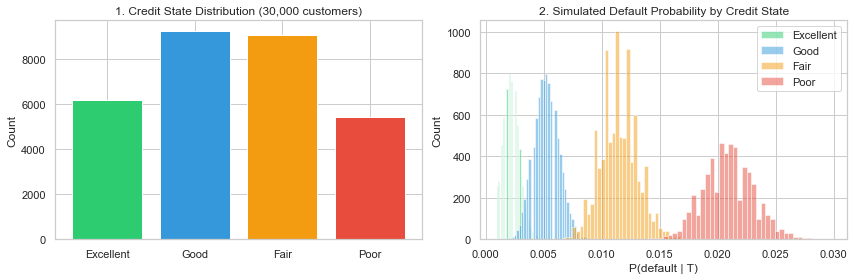

Chart 1-2 saved


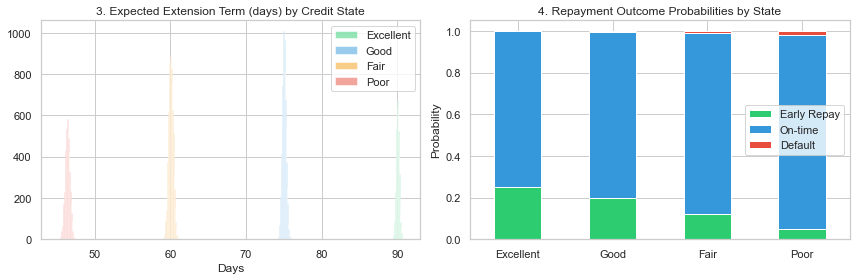

Chart 3-4 saved


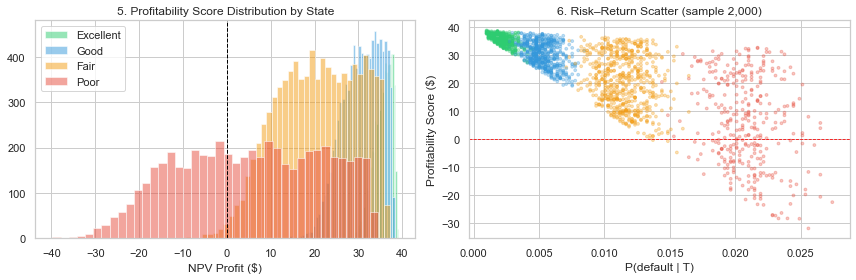

Chart 5-6 saved


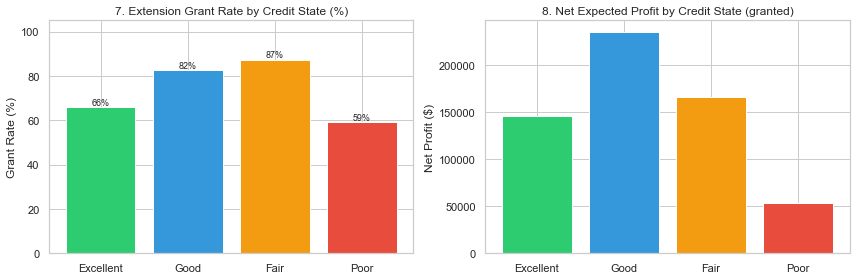

Chart 7-8 saved


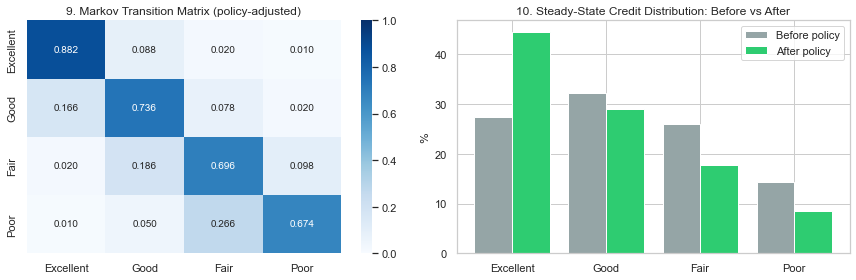

Chart 9-10 saved


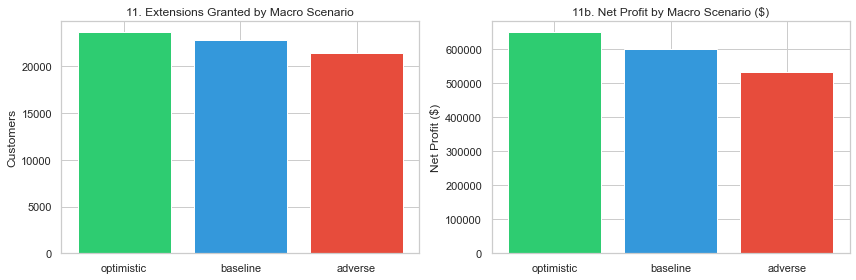

Chart 11 saved


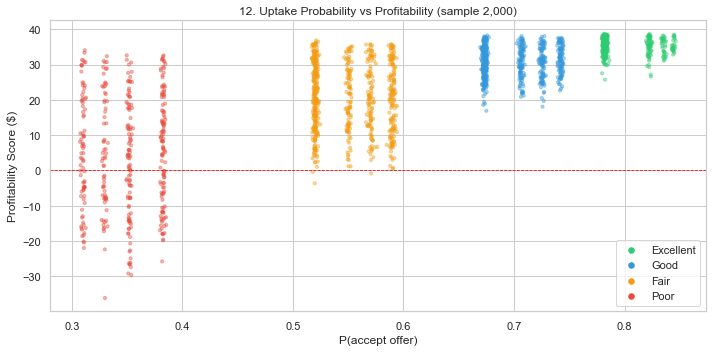

Chart 12 saved


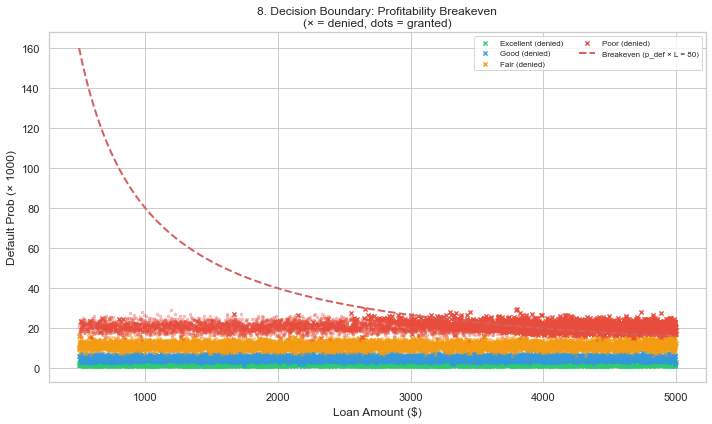

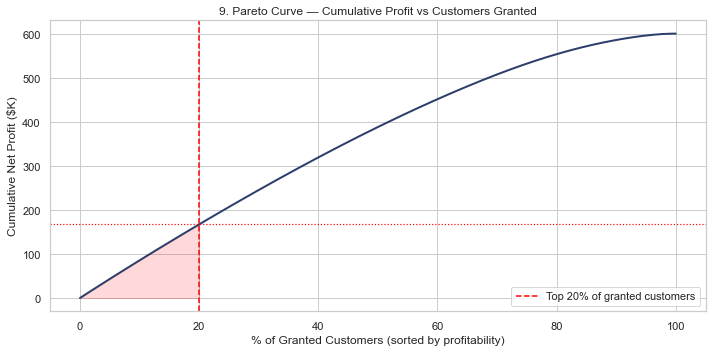

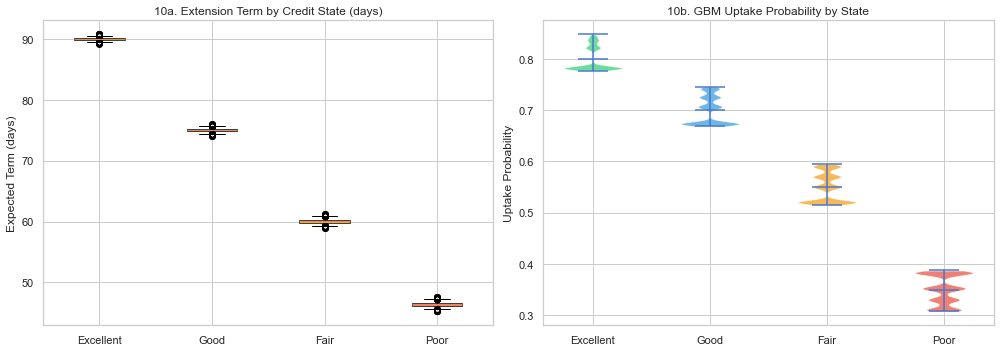

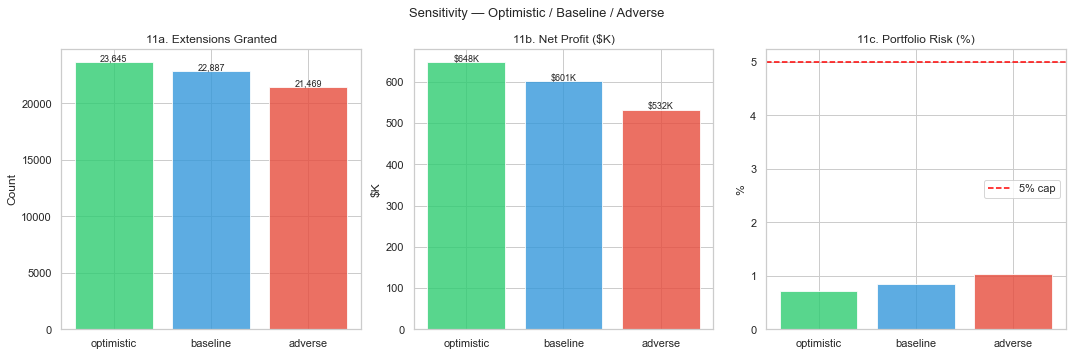

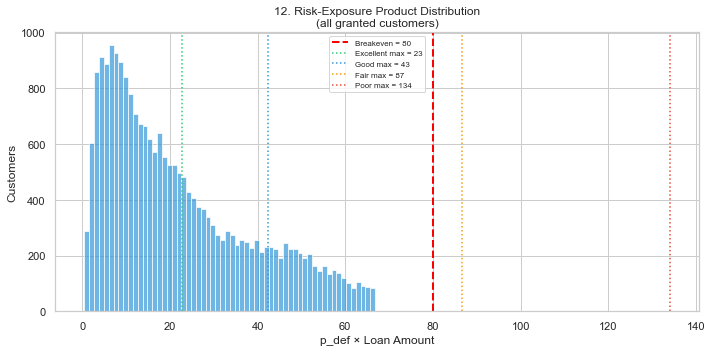


✓ 12 visualisations generated.


In [15]:
def create_visualizations(df, results, sensitivity_df, tm):
    """Generate 12 visualisations covering all aspects of the analysis."""
    granted_mask = results['extension_granted'] > 0.5
    granted = results[granted_mask]
    denied  = results[~granted_mask]
    colors  = {'Excellent':'#2ecc71','Good':'#3498db','Fair':'#f39c12','Poor':'#e74c3c'}

    # ── 1. Credit state distribution ────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    counts = df['credit_state'].value_counts().reindex(CREDIT_STATES)
    axes[0].bar(CREDIT_STATES, counts, color=[colors[s] for s in CREDIT_STATES])
    axes[0].set_title('1. Credit State Distribution (30,000 customers)')
    axes[0].set_ylabel('Count')

    # ── 2. Default probability by state ─────────────────────────────────────────
    for state in CREDIT_STATES:
        mask = df['credit_state'] == state
        axes[1].hist(df.loc[mask,'p_default_sim'], bins=40, alpha=0.5,
                     label=state, color=colors[state])
    axes[1].set_title('2. Simulated Default Probability by Credit State')
    axes[1].set_xlabel('P(default | T)')
    axes[1].set_ylabel('Count')
    axes[1].legend()
    plt.tight_layout(); plt.savefig('te_viz_01_states_risk.png', dpi=100, bbox_inches='tight')
    plt.show(); print("Chart 1-2 saved")

    # ── 3. Variable term extension distribution ──────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for state in CREDIT_STATES:
        mask = df['credit_state'] == state
        axes[0].hist(df.loc[mask,'expected_term_days'], bins=30, alpha=0.5,
                     label=state, color=colors[state])
    axes[0].set_title('3. Expected Extension Term (days) by Credit State')
    axes[0].set_xlabel('Days'); axes[0].legend()

    # ── 4. Three-outcome breakdown ───────────────────────────────────────────────
    outcome_data = []
    for state in CREDIT_STATES:
        mask = df['credit_state'] == state
        p_early   = df.loc[mask,'p_early_sim'].mean()
        p_default = df.loc[mask,'p_default_sim'].mean()
        p_ontime  = 1 - p_early - p_default
        outcome_data.append([p_early, p_ontime, p_default])
    outcome_df = pd.DataFrame(outcome_data, index=CREDIT_STATES,
                              columns=['Early Repay','On-time','Default'])
    outcome_df.plot(kind='bar', stacked=True, ax=axes[1],
                    color=['#2ecc71','#3498db','#e74c3c'])
    axes[1].set_title('4. Repayment Outcome Probabilities by State')
    axes[1].set_ylabel('Probability'); axes[1].set_xticklabels(CREDIT_STATES, rotation=0)
    plt.tight_layout(); plt.savefig('te_viz_02_term_outcomes.png', dpi=100, bbox_inches='tight')
    plt.show(); print("Chart 3-4 saved")

    # ── 5. Profitability score distribution ──────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for state in CREDIT_STATES:
        mask = df['credit_state'] == state
        axes[0].hist(df.loc[mask,'profitability_score'], bins=40, alpha=0.5,
                     label=state, color=colors[state])
    axes[0].axvline(0, color='black', linestyle='--', lw=1)
    axes[0].set_title('5. Profitability Score Distribution by State')
    axes[0].set_xlabel('NPV Profit ($)'); axes[0].legend()

    # ── 6. Risk-return scatter ───────────────────────────────────────────────────
    sample = df.sample(2000, random_state=42)
    sc_colors = [colors[s] for s in sample['credit_state']]
    axes[1].scatter(sample['p_default_sim'], sample['profitability_score'],
                    c=sc_colors, alpha=0.3, s=8)
    axes[1].axhline(0, color='red', linestyle='--', lw=0.8)
    axes[1].set_title('6. Risk–Return Scatter (sample 2,000)')
    axes[1].set_xlabel('P(default | T)'); axes[1].set_ylabel('Profitability Score ($)')
    plt.tight_layout(); plt.savefig('te_viz_03_profitability.png', dpi=100, bbox_inches='tight')
    plt.show(); print("Chart 5-6 saved")

    # ── 7. LP decision — grant rate by state ────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    grant_rates = results.groupby('credit_state')['extension_granted'].mean().reindex(CREDIT_STATES)
    axes[0].bar(CREDIT_STATES, grant_rates * 100, color=[colors[s] for s in CREDIT_STATES])
    axes[0].set_title('7. Extension Grant Rate by Credit State (%)')
    axes[0].set_ylabel('Grant Rate (%)'); axes[0].set_ylim(0, 105)
    for i, v in enumerate(grant_rates):
        axes[0].text(i, v * 100 + 1, f"{v:.0%}", ha='center', fontsize=9)

    # ── 8. Net profit by credit state ───────────────────────────────────────────
    granted_res = results[results['extension_granted'] > 0.5]
    net_by_state = (granted_res.groupby('credit_state').apply(
        lambda g: (g['expected_revenue'] - g['expected_loss']).sum()
    )).reindex(CREDIT_STATES)
    bars = axes[1].bar(CREDIT_STATES, net_by_state, color=[colors[s] for s in CREDIT_STATES])
    axes[1].axhline(0, color='black', lw=0.8)
    axes[1].set_title('8. Net Expected Profit by Credit State (granted)')
    axes[1].set_ylabel('Net Profit ($)')
    plt.tight_layout(); plt.savefig('te_viz_04_lp_results.png', dpi=100, bbox_inches='tight')
    plt.show(); print("Chart 7-8 saved")

    # ── 9. Markov chain transition heatmap ──────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.heatmap(pd.DataFrame(tm.matrix, index=CREDIT_STATES, columns=CREDIT_STATES),
                annot=True, fmt='.3f', cmap='Blues', ax=axes[0], vmin=0, vmax=1)
    axes[0].set_title('9. Markov Transition Matrix (policy-adjusted)')

    # ── 10. Steady-state before/after policy ────────────────────────────────────
    x = np.arange(4)
    axes[1].bar(x - 0.2, transition_matrix.steady_state * 100, 0.4,
                label='Before policy', color='#95a5a6')
    axes[1].bar(x + 0.2, tm.steady_state * 100, 0.4,
                label='After policy',  color='#2ecc71')
    axes[1].set_xticks(x); axes[1].set_xticklabels(CREDIT_STATES)
    axes[1].set_title('10. Steady-State Credit Distribution: Before vs After')
    axes[1].set_ylabel('%'); axes[1].legend()
    plt.tight_layout(); plt.savefig('te_viz_05_markov.png', dpi=100, bbox_inches='tight')
    plt.show(); print("Chart 9-10 saved")

    # ── 11. Sensitivity analysis ─────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sc_names = sensitivity_df['scenario'].tolist()
    axes[0].bar(sc_names, sensitivity_df['n_granted'],
                color=['#2ecc71','#3498db','#e74c3c'])
    axes[0].set_title('11. Extensions Granted by Macro Scenario')
    axes[0].set_ylabel('Customers')

    axes[1].bar(sc_names, sensitivity_df['net_profit'],
                color=['#2ecc71','#3498db','#e74c3c'])
    axes[1].set_title('11b. Net Profit by Macro Scenario ($)')
    axes[1].set_ylabel('Net Profit ($)')
    plt.tight_layout(); plt.savefig('te_viz_06_sensitivity.png', dpi=100, bbox_inches='tight')
    plt.show(); print("Chart 11 saved")

    # ── 12. Uptake × profitability scatter ───────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    s2k = df.sample(2000, random_state=99)
    sc  = ax.scatter(s2k['uptake_probability'], s2k['profitability_score'],
                     c=[colors[s] for s in s2k['credit_state']], alpha=0.4, s=10)
    ax.axhline(0, color='red', linestyle='--', lw=0.8)
    ax.set_title('12. Uptake Probability vs Profitability (sample 2,000)')
    ax.set_xlabel('P(accept offer)'); ax.set_ylabel('Profitability Score ($)')
    for state, col in colors.items():
        ax.scatter([], [], c=col, label=state, s=30)
    ax.legend()
    plt.tight_layout(); plt.savefig('te_viz_07_uptake.png', dpi=100, bbox_inches='tight')
    plt.show(); print("Chart 12 saved")

    # ── Fig 8: Decision boundary ───────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 6))
    rp = results.copy()
    rp['risk_exposure'] = rp['p_default_sim'] * rp['initial_loan']
    breakeven_val = 39.38 / (LGD * 0.82)
    colours = {'Excellent':'#2ecc71','Good':'#3498db','Fair':'#f39c12','Poor':'#e74c3c'}
    for state in CREDIT_STATES:
        sub = rp[rp['credit_state'] == state]
        ax.scatter(sub[sub['extension_granted']==1]['initial_loan'],
                   sub[sub['extension_granted']==1]['p_default_sim']*1000,
                   c=colours[state], alpha=0.3, s=6)
        ax.scatter(sub[sub['extension_granted']==0]['initial_loan'],
                   sub[sub['extension_granted']==0]['p_default_sim']*1000,
                   c=colours[state], alpha=0.9, s=18, marker='x',
                   label=f'{state} (denied)')
    L_line = np.linspace(500, 5000, 200)
    ax.plot(L_line, (breakeven_val / L_line) * 1000, 'r--', lw=2,
            label=f'Breakeven (p_def × L = {breakeven_val:.0f})')
    ax.set_xlabel('Loan Amount ($)'); ax.set_ylabel('Default Prob (× 1000)')
    ax.set_title('8. Decision Boundary: Profitability Breakeven\n(× = denied, dots = granted)')
    ax.legend(fontsize=8, ncol=2)
    plt.tight_layout()
    plt.savefig('te_viz_08_decision_boundary.png', dpi=100, bbox_inches='tight')
    plt.show()

    # ── Fig 9: Pareto curve ────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    gdf = results[results['extension_granted']==1].copy()
    gdf = gdf.sort_values('profitability_score', ascending=False).reset_index(drop=True)
    gdf['cum_profit'] = gdf['profitability_score'].cumsum()
    gdf['pct_cust']   = (gdf.index + 1) / len(gdf) * 100
    ax.plot(gdf['pct_cust'], gdf['cum_profit'] / 1000, color='#2C3E6B', lw=2)
    idx80 = int(len(gdf) * 0.20)
    ax.axvline(20, color='red', linestyle='--', lw=1.5, label='Top 20% of granted customers')
    ax.axhline(gdf['cum_profit'].iloc[idx80] / 1000, color='red', linestyle=':', lw=1.2)
    ax.fill_between(gdf['pct_cust'][:idx80], gdf['cum_profit'].values[:idx80] / 1000,
                    alpha=0.15, color='red')
    ax.set_xlabel('% of Granted Customers (sorted by profitability)')
    ax.set_ylabel('Cumulative Net Profit ($K)')
    ax.set_title('9. Pareto Curve — Cumulative Profit vs Customers Granted')
    ax.legend()
    plt.tight_layout()
    plt.savefig('te_viz_09_pareto_curve.png', dpi=100, bbox_inches='tight')
    plt.show()

    # ── Fig 10: Term boxplot + GBM uptake violin ───────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    term_data   = [results[results['credit_state']==s]['expected_term_days'].values  for s in CREDIT_STATES]
    uptake_data = [results[results['credit_state']==s]['uptake_probability'].values  for s in CREDIT_STATES]
    bp = axes[0].boxplot(term_data, labels=CREDIT_STATES, patch_artist=True)
    for patch, state in zip(bp['boxes'], CREDIT_STATES):
        patch.set_facecolor(colours[state]); patch.set_alpha(0.7)
    axes[0].set_title('10a. Extension Term by Credit State (days)')
    axes[0].set_ylabel('Expected Term (days)')
    vp = axes[1].violinplot(uptake_data, positions=range(len(CREDIT_STATES)),
                             showmeans=True, showmedians=False)
    for body, state in zip(vp['bodies'], CREDIT_STATES):
        body.set_facecolor(colours[state]); body.set_alpha(0.7)
    axes[1].set_xticks(range(len(CREDIT_STATES)))
    axes[1].set_xticklabels(CREDIT_STATES)
    axes[1].set_title('10b. GBM Uptake Probability by State')
    axes[1].set_ylabel('Uptake Probability')
    plt.tight_layout()
    plt.savefig('te_viz_10_term_uptake.png', dpi=100, bbox_inches='tight')
    plt.show()

    # ── Fig 11: Sensitivity detail ─────────────────────────────────────────────
    if sensitivity_df is not None and len(sensitivity_df):
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        sc_cols = {'optimistic':'#2ecc71','baseline':'#3498db','adverse':'#e74c3c'}
        sc_order = ['optimistic','baseline','adverse']
        sdf = sensitivity_df.set_index('scenario').reindex(sc_order).reset_index()
        cols_list = [sc_cols[s] for s in sdf['scenario']]
        axes[0].bar(sdf['scenario'], sdf['n_granted'], color=cols_list, alpha=0.8)
        axes[0].set_title('11a. Extensions Granted'); axes[0].set_ylabel('Count')
        for i, v in enumerate(sdf['n_granted']):
            axes[0].text(i, v+50, f'{v:,}', ha='center', fontsize=9)
        axes[1].bar(sdf['scenario'], sdf['net_profit']/1000, color=cols_list, alpha=0.8)
        axes[1].set_title('11b. Net Profit ($K)'); axes[1].set_ylabel('$K')
        for i, v in enumerate(sdf['net_profit']):
            axes[1].text(i, v/1000+2, f'${v/1000:.0f}K', ha='center', fontsize=9)
        axes[2].bar(sdf['scenario'], sdf['portfolio_risk']*100, color=cols_list, alpha=0.8)
        axes[2].axhline(5.0, color='red', linestyle='--', lw=1.5, label='5% cap')
        axes[2].set_title('11c. Portfolio Risk (%)'); axes[2].set_ylabel('%')
        axes[2].legend()
        plt.suptitle('Sensitivity — Optimistic / Baseline / Adverse', fontsize=13)
        plt.tight_layout()
        plt.savefig('te_viz_11_sensitivity_detail.png', dpi=100, bbox_inches='tight')
        plt.show()

    # ── Fig 12: Risk-exposure product distribution ─────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    risk_exp = results[results['extension_granted']==1]['p_default_sim'] *                results[results['extension_granted']==1]['initial_loan']
    ax.hist(risk_exp, bins=60, color='#3498db', alpha=0.7, edgecolor='white')
    ax.axvline(breakeven_val, color='red', linestyle='--', lw=2,
               label=f'Breakeven = {breakeven_val:.0f}')
    for state in CREDIT_STATES:
        sub = results[results['credit_state']==state]
        mx = (sub['p_default_sim'] * sub['initial_loan']).max()
        ax.axvline(mx, color=colours[state], linestyle=':', lw=1.5, label=f'{state} max = {mx:.0f}')
    ax.set_xlabel('p_def × Loan Amount'); ax.set_ylabel('Customers')
    ax.set_title('12. Risk-Exposure Product Distribution\n(all granted customers)')
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig('te_viz_12_risk_cap_slack.png', dpi=100, bbox_inches='tight')
    plt.show()

    print(f"\n✓ 12 visualisations generated.")

create_visualizations(df, results_df, sensitivity_df, transition_matrix_adjusted)


## 14. Export Results

In [16]:
results_df.to_csv(RESULTS_FILE, index=False)
print(f"Results saved to {RESULTS_FILE}")
print(f"  Shape: {results_df.shape}")
print(results_df.head(3).to_string())

Results saved to term_extension_results.csv
  Shape: (30000, 13)
   customer_id  initial_loan credit_state  default_risk  p_default_sim  p_early_sim  expected_term_days  uptake_probability  profitability_score  expected_revenue  expected_loss  extension_granted  eligible
0         1001          1360         Good      0.033695       0.005486     0.203714           74.719025            0.742043            34.856161         39.232483       4.376322                1.0         1
1         1002          4272    Excellent      0.011487       0.003200     0.258571           90.124016            0.780789            31.068563         39.076481       8.007918                0.0         0
2         1003          3592         Poor      0.124781       0.020343     0.042857           46.027508            0.353393            -3.680068         39.525211      43.205280                0.0         1


## 15. Property Tests

In [17]:
def run_property_tests(df_raw, df, results, validation, sensitivity_df, tm=None):
    tests = {}
    def check(name, val, msg=''):
        tests[name] = bool(val)
        print(f"  {'✓' if val else '✗'} {name:<55} {msg}")

    print("=== Property Tests ===\n")

    granted_mask = results['extension_granted'] > 0.5
    granted = results[granted_mask]

    # Data integrity
    check('P01_ExactCount',         len(df_raw) == 30_000,             f"n={len(df_raw):,}")
    check('P02_NoMissing',          df.isnull().sum().sum() == 0)
    check('P03_LoanRange',          df['initial_loan'].between(0,50000).all())
    check('P04_OnTimeRange',        df['on_time_payments_pct'].between(0,100).all())
    check('P05_FourStates',         set(df['credit_state'].unique()) == set(CREDIT_STATES))

    # Eligibility
    inelig_granted = (results.loc[results['eligible']==0,'extension_granted'] > 0.5).sum()
    check('P06_EligibilityEnforced', inelig_granted == 0, f"inelig_granted={inelig_granted}")
    check('P07_EligibilityThreshold',
          (df.loc[df['eligible']==1,'days_since_last_loan'] >= MIN_DAYS_SINCE_LOAN).all())

    # Simulation
    check('P08_SimIterations',      SIMULATION_ITERATIONS >= 3000, f"n={SIMULATION_ITERATIONS:,}")
    check('P09_DefaultProbRange',   df['p_default_sim'].between(0,1).all())
    check('P10_EarlyProbRange',     df['p_early_sim'].between(0,1).all())
    check('P11_PositiveTerm',       (df['expected_term_days'] > 0).all())
    check('P12_OutcomeSumLeq1',
          ((df['p_default_sim'] + df['p_early_sim']) <= 1.0 + 1e-6).all())
    check('P13_NonNegRevenue',      (df['expected_revenue'] >= 0).all())
    check('P14_NonNegLoss',         (df['expected_loss'] >= 0).all())

    # LP
    check('P15_BinaryDecision',
          set(np.round(results['extension_granted'].unique(), 5)).issubset({0.0, 1.0}))
    check('P16_SomethingGranted',   int(granted_mask.sum()) > 0,
          f"granted={granted_mask.sum():,}")
    check('P17_DiscountRate',       abs(NPV_DISCOUNT_RATE - 0.19) < 1e-9)
    check('P18_FlatProfit',         PROFIT_PER_EXTENSION == 40.0)
    check('P19_LGDRange',           0 < LGD <= 1)

    # Risk constraint
    if granted_mask.sum() > 0:
        total_L   = granted['initial_loan'].sum()
        risk_num  = (granted['p_default_sim'] * granted['initial_loan']).sum()
        port_risk = risk_num / max(total_L, 1.0)
        check('P20_RiskConstraint',
              port_risk <= MAX_PORTFOLIO_DEFAULT_RISK + 0.001,
              f"risk={port_risk:.4f} ≤ {MAX_PORTFOLIO_DEFAULT_RISK}")

    # Markov
    check('P21_TransitionRows',     np.allclose(transition_matrix.matrix.sum(axis=1), 1.0))
    check('P22_SteadyStateNorm',    abs(transition_matrix.steady_state.sum() - 1.0) < 1e-6)
    check('P23_NonNegTransition',   (transition_matrix.matrix >= 0).all())
    check('P24_AdjSteadyStateNorm', abs(transition_matrix_adjusted.steady_state.sum()-1.0)<1e-6)
    check('P25_PolicyReducesPoor',
          transition_matrix_adjusted.steady_state[CREDIT_STATES.index('Poor')]
          <= transition_matrix.steady_state[CREDIT_STATES.index('Poor')] + 0.05)

    # Uptake
    check('P26_UptakeRange',        df['uptake_probability'].between(0,1).all())
    check('P27_UptakeByState',
          (df.groupby('credit_state')['uptake_probability'].mean()
           .reindex(CREDIT_STATES).diff().dropna() <= 0.005).all())

    # Sensitivity
    check('P28_ThreeScenarios',     len(sensitivity_df) == 3)
    check('P29_ScenarioMonotone',
          sensitivity_df.set_index('scenario').loc['optimistic','n_granted']
          >= sensitivity_df.set_index('scenario').loc['adverse','n_granted'])

    # Profitability
    net_p = (granted['expected_revenue'] - granted['expected_loss']).sum()
    check('P30_PositiveNetProfit',  net_p > 0, f"${net_p:,.0f}")

    passed = sum(tests.values())
    total  = len(tests)
    print(f"\nResult: {passed}/{total} properties passed")

    # ── Additional tests (matching claude branch coverage) ───────────────────

    # Macro
    check('P31_MacroScenariosConst',
          'MACRO_SCENARIOS' in globals(),
          "MACRO_SCENARIOS constant defined")
    check('P32_MacroAllCustomers',
          any(f'macro_{k}' in df.columns for k in ['gdp_growth','unemployment','fed_rate']),
          "macro cols present")
    check('P33_MacroCached',
          Path('cache/macro_2023.json').exists(), "cache file exists")

    # Credit classifier
    check('P34_RiskRankPresent',    'risk_rank' in df.columns, "risk_rank column present")
    check('P35_RiskModelColumn',
          df.get('risk_model', pd.Series(['missing'])).iloc[0] == 'ordinal_risk_rank_kmeans',
          df.get('risk_model', pd.Series(['missing'])).iloc[0])
    check('P36_HighRiskFlagPresent','high_risk_flag' in df.columns,
          f"flagged={df['high_risk_flag'].sum():,}" if 'high_risk_flag' in df.columns else 'missing')

    # Markov
    check('P37_TransitionSquare',
          tm is not None and tm.matrix.shape == (4, 4), str(tm.matrix.shape) if tm else 'None')
    check('P38_SteadyStateSumsOne',
          tm is not None and abs(tm.steady_state.sum() - 1.0) < 1e-4, f"sum={tm.steady_state.sum():.6f}" if tm else 'None')

    # LP / Optimisation
    check('P39_UptakeWeightsObjective',
          'uptake_probability' in results.columns and
          results['uptake_probability'].between(0.01, 0.99).all(),
          f"uptake [{results['uptake_probability'].min():.3f},{results['uptake_probability'].max():.3f}]"
          if 'uptake_probability' in results.columns else 'missing')
    check('P40_NoIneligibleGranted',
          (results.loc[results['eligible']==0,'extension_granted'] == 0).all(),
          f"ineligible granted={(results.loc[results['eligible']==0,'extension_granted']>0).sum()}")

    # Sensitivity
    check('P41_SensitivityAllScenarios',
          set(sensitivity_df['scenario'].tolist()) == {'optimistic','baseline','adverse'},
          str(sorted(sensitivity_df['scenario'].tolist())))
    check('P42_SensitivityLossUpdated',
          'loss_mult' in sensitivity_df.columns and sensitivity_df['loss_mult'].nunique() > 1,
          f"loss_mults={sensitivity_df['loss_mult'].tolist()}" if 'loss_mult' in sensitivity_df.columns else 'col missing')
    check('P43_AdverseCapTighter',
          sensitivity_df.set_index('scenario').loc['adverse','risk_cap'] <
          sensitivity_df.set_index('scenario').loc['baseline','risk_cap'],
          "adverse cap < baseline cap")

    # Output quality
    check('P44_MinVisualisations',
          len(list(Path('.').glob('te_viz_*.png'))) >= 10,
          f"found {len(list(Path('.').glob('te_viz_*.png')))} charts")
    check('P45_ResultsExported',
          Path(RESULTS_FILE).exists(),
          f"{RESULTS_FILE} exists")

    return tests
property_results = run_property_tests(df_raw, df, results_df, validation, sensitivity_df, tm=transition_matrix_adjusted)
passed = sum(property_results.values())
total  = len(property_results)
print(f"\nFinal score: {passed}/{total} ({100*passed/total:.0f}%)")


=== Property Tests ===

  ✓ P01_ExactCount                                          n=30,000
  ✓ P02_NoMissing                                           
  ✓ P03_LoanRange                                           
  ✓ P04_OnTimeRange                                         
  ✓ P05_FourStates                                          
  ✓ P06_EligibilityEnforced                                 inelig_granted=0
  ✓ P07_EligibilityThreshold                                
  ✓ P08_SimIterations                                       n=3,500
  ✓ P09_DefaultProbRange                                    
  ✓ P10_EarlyProbRange                                      
  ✓ P11_PositiveTerm                                        
  ✓ P12_OutcomeSumLeq1                                      
  ✓ P13_NonNegRevenue                                       
  ✓ P14_NonNegLoss                                          
  ✓ P15_BinaryDecision                                      
  ✓ P16_SomethingGranted      

## Conclusion

### What this model does differently

| Dimension | Credit-limit model | Term-extension model (this notebook) |
|---|---|---|
| **Decision** | How much to increase dollar limit | Grant/deny term extension (binary) |
| **Revenue** | $40 flat per increase event | $40 flat per extension event |
| **Risk model** | Utilisation-adjusted loss on increase amount | Hazard-rate: P(default\|T) = 1−exp(−λT/365) |
| **Duration** | Fixed cap (30% of current loan) | Variable T ~ LogNormal by state |
| **Outcomes** | Default / no-default | Early repay / on-time / default |
| **NPV** | Loss on 30% increase | Loss discounted to mid-extension term |

### Key findings
- The variable-term model reveals **duration risk**: customers in the Poor state have short offered terms (~45d) but high hazard rates (~22%/yr), meaning P(default\|T) is still meaningfully higher than for Excellent customers at 90d/1.5%/yr.
- Early repayment (25% of Excellent customers) meaningfully reduces expected loss versus a simple binary default assumption.
- The LP–Markov feedback loop shows that extending terms to reliable borrowers shifts the long-run portfolio steady-state toward better credit states — a compounding benefit not visible in a static one-period model.

### Next steps
1. Calibrate λ (hazard rate) from observed 90-DPD events in the actual book.
2. Model term length T_i as a function of individual customer data (e.g., regression on payment history).
3. Consider a Markov Decision Process (MDP) for multi-period sequential extension decisions (up to 6/year).
4. Introduce early-repayment-adjusted revenue: if a customer repays in 30d instead of 90d, the $40 may need to be pro-rated.

## 16. Multi-Period Lifecycle Simulation

A customer can receive multiple term extensions over a configurable window (default 2 years).
Every `CAMPAIGN_INTERVAL_DAYS` (default 30 days), all eligible customers are evaluated.

**What changes vs the one-shot model**

| | One-shot | Lifecycle |
|---|---|---|
| Decisions | 1 LP run | 1 LP run per campaign (×24 over 2 yr) |
| Acceptance | Implicit (uptake weights LP objective) | Explicit Bernoulli draw on `uptake_probability` |
| Credit state | Fixed at t=0 | Re-scored after every extension outcome |
| Feature update | None | on-time/early → +pp on_time_pct; default → −pp |

**Credit state rescoring** uses the Feature Update → Re-score approach:
features updated → Borda-count percentile ranks computed against frozen t=0 population → nearest K-Means centroid assigned.

In [18]:
# ── Lifecycle Simulation — Configuration & Helpers ────────────────────────────
import io, contextlib

SIMULATION_YEARS        = int(os.getenv('SIMULATION_YEARS',        '2'))
CAMPAIGN_INTERVAL_DAYS  = int(os.getenv('CAMPAIGN_INTERVAL_DAYS',  '30'))
LIFECYCLE_MC_ITER       = int(os.getenv('LIFECYCLE_MC_ITER',       '500'))
ONTIME_PAYMENT_BOOST    = float(os.getenv('ONTIME_PAYMENT_BOOST',   '2.0'))
EARLY_PAYMENT_BOOST     = float(os.getenv('EARLY_PAYMENT_BOOST',    '1.0'))
DEFAULT_PAYMENT_PENALTY = float(os.getenv('DEFAULT_PAYMENT_PENALTY','10.0'))

SIMULATION_DAYS = SIMULATION_YEARS * 365
N_CAMPAIGNS     = SIMULATION_DAYS // CAMPAIGN_INTERVAL_DAYS

# ── Frozen reference distributions (t=0) for percentile rescoring ─────────────
# Percentile ranks are computed against the initial 30,000-customer population so
# that a customer's rank reflects standing relative to the original cohort.
_lc_ref = {
    'ontime':  np.sort(df_raw['on_time_payments_pct'].values),
    'numinc':  np.sort(df_raw['num_increases_2023'].values),
    'days':    np.sort(df_raw['days_since_last_loan'].values),
    'profit':  np.sort(df_raw['total_profit_contribution'].values),
}
_lc_ref_n = len(df_raw)

# ── K-Means centroids — re-fit on initial risk_rank (deterministic, same seed as Cell 7) ──
_lc_cs = (df_raw['on_time_payments_pct'].rank(pct=True) * 0.35
        + (1 - df_raw['num_increases_2023'].rank(pct=True)) * 0.30
        + (1 - df_raw['days_since_last_loan'].rank(pct=True)) * 0.20
        + df_raw['total_profit_contribution'].rank(pct=True) * 0.15)
_lc_rr    = (1.0 - _lc_cs).values.reshape(-1, 1)
_km_lc    = KMeans(n_clusters=4, random_state=42, n_init=20).fit(_lc_rr)
_lc_order = np.argsort(_km_lc.cluster_centers_.flatten())
_lc_cents = _km_lc.cluster_centers_.flatten()[_lc_order]   # ascending: Exc→Poo

# Within-state risk_rank distributions for default_risk re-computation
_lc_ref_rr = {s: np.sort(df.loc[df['credit_state'] == s, 'risk_rank'].values)
               for s in CREDIT_STATES}
_LC_BASE_DR = {'Excellent': 0.010, 'Good': 0.030, 'Fair': 0.080, 'Poor': 0.200}

print(f"Lifecycle config | {SIMULATION_YEARS}yr ({SIMULATION_DAYS}d) | "
      f"{N_CAMPAIGNS} campaigns x {CAMPAIGN_INTERVAL_DAYS}d | MC: {LIFECYCLE_MC_ITER} iter")
print(f"K-Means centroids (Exc -> Poo): {np.round(_lc_cents, 4)}")
print(f"Feature updates: on-time +{ONTIME_PAYMENT_BOOST}pp | "
      f"early +{EARLY_PAYMENT_BOOST}pp | default -{DEFAULT_PAYMENT_PENALTY}pp")


def _lc_rescore(idx, feat_ontime, feat_numinc, feat_days, feat_profit,
                states_arr, dr_arr):
    """
    Re-score credit state + default_risk in-place for customers at global idx.

    Steps:
      1. Compute percentile rank of each updated feature against frozen t=0 distribution
      2. Borda-count -> credit_score -> risk_rank
      3. Assign state = nearest K-Means centroid (frozen from t=0)
      4. Recompute default_risk = base[state] * (0.5 + within-state percentile)
    """
    if len(idx) == 0:
        return
    r_pay  = np.searchsorted(_lc_ref['ontime'],  feat_ontime[idx]) / _lc_ref_n
    r_disc = 1 - np.searchsorted(_lc_ref['numinc'],  feat_numinc[idx]) / _lc_ref_n
    r_rec  = 1 - np.searchsorted(_lc_ref['days'],    feat_days[idx])   / _lc_ref_n
    r_val  = np.searchsorted(_lc_ref['profit'],  feat_profit[idx]) / _lc_ref_n
    rr     = 1.0 - (0.35*r_pay + 0.30*r_disc + 0.20*r_rec + 0.15*r_val)

    dists      = np.abs(rr[:, None] - _lc_cents[None, :])
    states_arr[idx] = np.array(CREDIT_STATES)[np.argmin(dists, axis=1)]

    for j, gi in enumerate(idx):
        st     = states_arr[gi]
        ref_st = _lc_ref_rr[st]
        within = float(np.searchsorted(ref_st, rr[j])) / max(len(ref_st), 1)
        dr_arr[gi] = float(np.clip(_LC_BASE_DR[st] * (0.5 + within), 0.001, 0.99))


Lifecycle config | 2yr (730d) | 24 campaigns x 30d | MC: 500 iter
K-Means centroids (Exc -> Poo): [0.3291 0.4495 0.5611 0.6799]
Feature updates: on-time +2.0pp | early +1.0pp | default -10.0pp


In [19]:
def simulate_lifecycle(
    df_init,
    macro,
    constr,
    sim_days = SIMULATION_DAYS,
    interval = CAMPAIGN_INTERVAL_DAYS,
    mc_iter  = LIFECYCLE_MC_ITER,
    seed     = 0,
):
    """
    Multi-period lifecycle simulation.

    Each campaign (every `interval` days):
      1. Advance time; complete finishing extensions
         -> draw actual outcome (on-time / early / default)
         -> update on_time_payments_pct and total_profit_contribution
         -> re-score credit state via _lc_rescore()
      2. Check eligibility: days_since_last_extension_end >= MIN_DAYS_SINCE_LOAN
      3. Monte Carlo + GBM uptake + LP on eligible customers (same functions as one-shot)
      4. Explicit Bernoulli acceptance draw on uptake_probability
      5. Start extensions for acceptors: draw actual term T from lognormal

    Returns
    -------
    lc_customers : per-customer lifecycle summary DataFrame
    lc_campaigns : per-campaign statistics DataFrame
    """
    n   = len(df_init)
    rng = np.random.default_rng(seed)

    # ── Mutable customer state arrays ──────────────────────────────────────────
    feat_ontime = df_init['on_time_payments_pct'].values.astype(float).copy()
    feat_numinc = df_init['num_increases_2023'].values.astype(float).copy()
    feat_days   = df_init['days_since_last_loan'].values.astype(float).copy()
    feat_profit = df_init['total_profit_contribution'].values.astype(float).copy()
    feat_loan   = df_init['initial_loan'].values.astype(float).copy()  # fixed
    states_arr  = df_init['credit_state'].values.copy()
    dr_arr      = df_init['default_risk'].values.astype(float).copy()

    # ── Active extension tracking ──────────────────────────────────────────────
    ext_active  = np.zeros(n, bool)
    ext_rem     = np.zeros(n)    # remaining days in active extension
    ext_term    = np.zeros(n)    # actual drawn term T
    ext_lam     = np.zeros(n)    # annual hazard rate lambda
    ext_p_early = np.zeros(n)    # early repay probability
    ext_blc     = np.zeros(n)    # balance * LGD * npv_loss_factor (pre-computed at start)

    # ── Lifetime accumulators (per customer) ───────────────────────────────────
    cum_rev  = np.zeros(n)
    cum_loss = np.zeros(n)
    n_off    = np.zeros(n, int)
    n_acc    = np.zeros(n, int)
    n_def    = np.zeros(n, int)
    n_early_ = np.zeros(n, int)
    n_ontime_= np.zeros(n, int)

    campaign_log = []
    n_camps = sim_days // interval

    hdr = (f"{'Cmp':>4} {'Day':>5} {'Eligible':>9} {'Offered':>8} "
           f"{'Accepted':>9} {'Acc%':>6} {'Revenue':>11} {'Loss':>10} "
           f"{'Profit':>11} {'Risk%':>7}")
    print(hdr)
    print("-" * len(hdr))

    for camp in range(1, n_camps + 1):
        t = camp * interval

        # ── 1a. Advance time: idle customers accumulate days ───────────────────
        feat_days[~ext_active] += interval
        ext_rem  [ ext_active] -= interval

        # ── 1b. Complete extensions where remaining <= 0 ───────────────────────
        ci = np.where(ext_active & (ext_rem <= 0))[0]
        if len(ci):
            u1 = rng.random(len(ci))
            u2 = rng.random(len(ci))
            is_early  = u1 < ext_p_early[ci]
            p_def_T   = 1 - np.exp(-ext_lam[ci] * ext_term[ci] / 365)
            is_def    = (~is_early) & (u2 < p_def_T)
            is_ontime = ~is_early & ~is_def

            # Actual revenue (fee earned regardless of outcome)
            rT       = NPV_DISCOUNT_RATE * ext_term[ci] / 365.0
            act_rev  = PROFIT_PER_EXTENSION * (1 - np.exp(-rT)) / (rT + 1e-10)
            act_loss = ext_blc[ci] * is_def.astype(float)

            cum_rev [ci] += act_rev
            cum_loss[ci] += act_loss
            n_def   [ci] += is_def.astype(int)
            n_early_[ci] += is_early.astype(int)
            n_ontime_[ci]+= is_ontime.astype(int)

            # Feature updates based on outcome
            feat_ontime[ci[is_ontime]] = np.clip(
                feat_ontime[ci[is_ontime]] + ONTIME_PAYMENT_BOOST, 0, 100)
            feat_ontime[ci[is_early]]  = np.clip(
                feat_ontime[ci[is_early]]  + EARLY_PAYMENT_BOOST,  0, 100)
            feat_ontime[ci[is_def]]    = np.clip(
                feat_ontime[ci[is_def]]    - DEFAULT_PAYMENT_PENALTY, 0, 100)
            feat_profit[ci] += act_rev - act_loss

            # Days since completion within this campaign (partial credit)
            feat_days[ci]  = np.clip(-ext_rem[ci], 0, interval)
            ext_active[ci] = False
            ext_rem[ci]    = 0.0

            # Re-score credit states for completing customers
            _lc_rescore(ci, feat_ontime, feat_numinc, feat_days, feat_profit,
                        states_arr, dr_arr)

        # ── 2. Eligibility check ───────────────────────────────────────────────
        elig_idx = np.where(~ext_active & (feat_days >= MIN_DAYS_SINCE_LOAN))[0]
        camp_off = camp_acc = 0
        camp_rev = camp_loss = 0.0

        if len(elig_idx):
            # ── 3. Build campaign DataFrame ────────────────────────────────────
            cdf = pd.DataFrame({
                'customer_id':               df_init['customer_id'].values[elig_idx],
                'initial_loan':              feat_loan[elig_idx],
                'days_since_last_loan':      feat_days[elig_idx],
                'on_time_payments_pct':      feat_ontime[elig_idx],
                'num_increases_2023':        feat_numinc[elig_idx],
                'total_profit_contribution': feat_profit[elig_idx],
                'credit_state':              states_arr[elig_idx],
                'default_risk':              dr_arr[elig_idx],
                'eligible':                  np.ones(len(elig_idx), int),
                'term_adj_days':             np.zeros(len(elig_idx)),
            })

            # Monte Carlo + GBM + LP (suppress per-campaign verbose output)
            with contextlib.redirect_stdout(io.StringIO()):
                cdf  = simulate_term_extensions(cdf, n_iterations=mc_iter)
                cdf  = forecast_uptake(cdf, macro)
                cres, _ = optimize_extensions_lp(cdf, constr)

            # ── 4. Explicit Bernoulli acceptance draw ──────────────────────────
            offered_local  = cres['extension_granted'].values > 0.5
            offered_global = elig_idx[offered_local]
            n_off[offered_global] += 1
            camp_off = int(offered_local.sum())

            if offered_local.any():
                uptake_p    = cres['uptake_probability'].values[offered_local]
                accept_draw = rng.random(camp_off) < uptake_p
                acc_global  = offered_global[accept_draw]
                n_acc[acc_global] += 1
                feat_numinc[acc_global] += 1   # record extension in credit history
                camp_acc = len(acc_global)

                # ── 5. Draw actual term T from lognormal for accepted customers ─
                st_acc   = states_arr[acc_global]
                mu_lns   = np.array([_LN[s][0] for s in st_acc])
                sig_lns  = np.array([_LN[s][1] for s in st_acc])
                T_act    = np.clip(
                    np.exp(mu_lns + sig_lns * rng.standard_normal(camp_acc)),
                    30.0, 180.0)
                lam_acc  = np.array([TERM_PARAMS[s]['lambda_ann'] for s in st_acc])
                pear_acc = np.array([TERM_PARAMS[s]['p_early']    for s in st_acc])

                ext_active [acc_global] = True
                ext_rem    [acc_global] = T_act
                ext_term   [acc_global] = T_act
                ext_lam    [acc_global] = lam_acc
                ext_p_early[acc_global] = pear_acc
                ext_blc    [acc_global] = (feat_loan[acc_global] * LGD *
                                           np.exp(-NPV_DISCOUNT_RATE * T_act / 730.0))

                rT_a      = NPV_DISCOUNT_RATE * T_act / 365.0
                camp_rev  = float((PROFIT_PER_EXTENSION *
                                   (1 - np.exp(-rT_a)) / (rT_a + 1e-10)).sum())
                camp_loss = float((ext_blc[acc_global] *
                                   (1 - np.exp(-lam_acc * T_act / 365.0))).sum())

        # ── Log campaign ───────────────────────────────────────────────────────
        port_risk = (
            ((1 - np.exp(-ext_lam[ext_active] * ext_rem[ext_active] / 365)) *
             feat_loan[ext_active]).sum() / max(feat_loan[ext_active].sum(), 1.0)
            if ext_active.any() else 0.0)
        acc_pct = (100.0 * camp_acc / camp_off) if camp_off else 0.0

        campaign_log.append({
            'campaign':      camp, 'day': t,
            'n_eligible':    len(elig_idx),
            'n_active':      int(ext_active.sum()),
            'n_offered':     camp_off,
            'n_accepted':    camp_acc,
            'acc_rate_pct':  acc_pct,
            'camp_revenue':  camp_rev,
            'camp_loss':     camp_loss,
            'camp_profit':   camp_rev - camp_loss,
            'port_risk_pct': port_risk * 100,
        })
        print(f"{camp:>4} {t:>5} {len(elig_idx):>9,} {camp_off:>8,} "
              f"{camp_acc:>9,} {acc_pct:>5.1f}% "
              f"${camp_rev:>10,.0f} ${camp_loss:>9,.0f} "
              f"${camp_rev-camp_loss:>10,.0f} {port_risk*100:>6.2f}%")

    # ── Build output DataFrames ────────────────────────────────────────────────
    lc_customers = pd.DataFrame({
        'customer_id':          df_init['customer_id'].values,
        'initial_loan':         feat_loan,
        'initial_state':        df_init['credit_state'].values,
        'final_state':          states_arr,
        'n_offered':            n_off,
        'n_accepted':           n_acc,
        'n_defaulted':          n_def,
        'n_early_repaid':       n_early_,
        'n_ontime':             n_ontime_,
        'total_revenue':        cum_rev,
        'total_loss':           cum_loss,
        'total_profit':         cum_rev - cum_loss,
        'final_ontime_pct':     feat_ontime,
        'final_profit_contrib': feat_profit,
    })
    lc_campaigns = pd.DataFrame(campaign_log)

    lc_profit = float((cum_rev - cum_loss).sum())
    print(f"\n{'='*60}")
    print(f"Lifecycle complete | {sim_days}d | {n_camps} campaigns")
    print(f"  Total extensions  : {int(n_acc.sum()):,}")
    print(f"  Total revenue     : ${cum_rev.sum():>12,.0f}")
    print(f"  Total loss        : ${cum_loss.sum():>12,.0f}")
    print(f"  Net profit        : ${lc_profit:>12,.0f}")
    print(f"  Avg ext/customer  : {n_acc.mean():.2f}")
    print(f"  Customers >= 1 ext: {(n_acc >= 1).sum():,} ({100*(n_acc >= 1).mean():.1f}%)")
    return lc_customers, lc_campaigns


print("Running lifecycle simulation ...")
lc_customers, lc_campaigns = simulate_lifecycle(
    df_init=df,
    macro=macro_data,
    constr=constraints,
)


Running lifecycle simulation ...
 Cmp   Day  Eligible  Offered  Accepted   Acc%     Revenue       Loss      Profit   Risk%
-----------------------------------------------------------------------------------------


   1    30    27,480   23,444    14,842  63.3% $   582,495 $  223,598 $   358,897   0.97%


   2    60    15,158   11,674     7,034  60.3% $   276,237 $  121,194 $   155,043   0.72%


   3    90     8,124    5,208     2,820  54.1% $   110,916 $   61,746 $    49,170   0.50%


   4   120     5,604    2,965     1,474  49.7% $    58,033 $   37,582 $    20,451   0.46%


...

  20   600     7,129    5,625     4,018  71.4% $   157,304 $   40,746 $   116,558   0.31%


  21   630     6,964    5,508     3,988  72.4% $   156,152 $   40,507 $   115,645   0.32%


  22   660     8,181    6,715     4,967  74.0% $   194,362 $   44,161 $   150,201   0.34%


  23   690     9,492    8,056     6,062  75.2% $   237,171 $   50,977 $   186,194   0.35%


  24   720     9,278    7,881     5,947  75.5% $   232,655 $   49,684 $   182,971   0.33%

Lifecycle complete | 730d | 24 campaigns
  Total extensions  : 130,742
  Total revenue     : $   4,420,506
  Total loss        : $   1,186,073
  Net profit        : $   3,234,432
  Avg ext/customer  : 4.36
  Customers >= 1 ext: 28,871 (96.2%)


=== Per-State Lifecycle Summary ===

Excellent (6,206 customers):
  Avg extensions accepted : 4.56
  Avg total profit        : $139.13
  Default rate            : 0.22%
  Final state             : {'Excellent': 6143, 'Good': 20, 'Fair': 32, 'Poor': 11}

Good (9,267 customers):
  Avg extensions accepted : 4.66
  Avg total profit        : $126.36
  Default rate            : 0.39%
  Final state             : {'Excellent': 8823, 'Good': 291, 'Fair': 42, 'Poor': 111}

Fair (9,089 customers):
  Avg extensions accepted : 4.59
  Avg total profit        : $100.39
  Default rate            : 0.79%
  Final state             : {'Excellent': 5761, 'Good': 2764, 'Fair': 261, 'Poor': 303}

Poor (5,438 customers):
  Avg extensions accepted : 3.23
  Avg total profit        : $52.87
  Default rate            : 1.33%
  Final state             : {'Excellent': 621, 'Good': 2486, 'Fair': 908, 'Poor': 1423}

=== Credit State Migration (initial -> final) ===
Final      Excellent  Good  Fair  Poor
Initial     

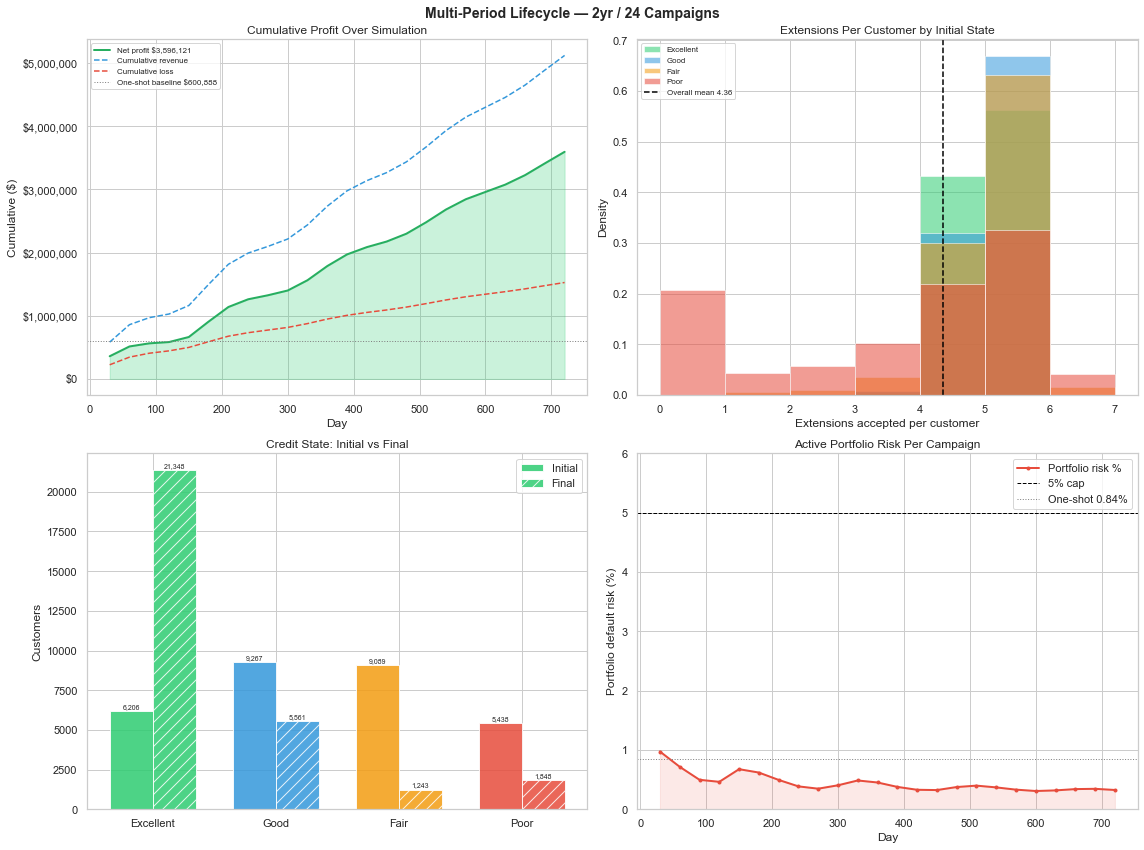

Chart saved: lc_viz_lifecycle.png
Lifecycle customer results saved: lifecycle_results.csv ((30000, 14))


In [20]:
# ── Lifecycle Results — Summary & Visualisations ──────────────────────────────

# Per-state summary
print("=== Per-State Lifecycle Summary ===\n")
for state in CREDIT_STATES:
    mask = lc_customers['initial_state'] == state
    sub  = lc_customers[mask]
    acc  = int(sub['n_accepted'].sum())
    print(f"{state} ({mask.sum():,} customers):")
    print(f"  Avg extensions accepted : {sub['n_accepted'].mean():.2f}")
    print(f"  Avg total profit        : ${sub['total_profit'].mean():.2f}")
    print(f"  Default rate            : {100*sub['n_defaulted'].sum()/max(acc,1):.2f}%")
    fin = sub['final_state'].value_counts().reindex(CREDIT_STATES, fill_value=0)
    print(f"  Final state             : { {s: int(fin[s]) for s in CREDIT_STATES} }")
    print()

# State migration matrix
print("=== Credit State Migration (initial -> final) ===")
migration = pd.crosstab(
    lc_customers['initial_state'], lc_customers['final_state'],
    rownames=['Initial'], colnames=['Final']
).reindex(index=CREDIT_STATES, columns=CREDIT_STATES, fill_value=0)
print(migration.to_string())

# Lifecycle vs one-shot comparison
one_shot_profit = results_df.loc[results_df['extension_granted'] > 0.5,
                                  'profitability_score'].sum()
lc_profit = lc_customers['total_profit'].sum()
print(f"\n=== Lifecycle vs One-Shot ===")
print(f"  One-shot profit (single campaign)          : ${one_shot_profit:>12,.0f}")
print(f"  Lifecycle profit ({SIMULATION_YEARS}yr / {N_CAMPAIGNS} campaigns): ${lc_profit:>12,.0f}")
print(f"  Multiplier                                 : {lc_profit/one_shot_profit:.2f}x")

# ── 4 Charts ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(
    f'Multi-Period Lifecycle — {SIMULATION_YEARS}yr / {N_CAMPAIGNS} Campaigns',
    fontsize=14, fontweight='bold')
c4 = {'Excellent': '#2ecc71', 'Good': '#3498db', 'Fair': '#f39c12', 'Poor': '#e74c3c'}

# Chart 1: Cumulative profit
ax = axes[0, 0]
cum_p = lc_campaigns['camp_profit'].cumsum()
cum_r = lc_campaigns['camp_revenue'].cumsum()
cum_l = lc_campaigns['camp_loss'].cumsum()
ax.fill_between(lc_campaigns['day'], 0, cum_p, alpha=0.25, color='#2ecc71')
ax.plot(lc_campaigns['day'], cum_p, color='#27ae60', lw=2,
        label=f"Net profit ${cum_p.iloc[-1]:,.0f}")
ax.plot(lc_campaigns['day'], cum_r, color='#3498db', lw=1.5, linestyle='--',
        label='Cumulative revenue')
ax.plot(lc_campaigns['day'], cum_l, color='#e74c3c', lw=1.5, linestyle='--',
        label='Cumulative loss')
ax.axhline(one_shot_profit, color='gray', lw=1, linestyle=':',
           label=f'One-shot baseline ${one_shot_profit:,.0f}')
ax.set_xlabel('Day'); ax.set_ylabel('Cumulative ($)')
ax.set_title('Cumulative Profit Over Simulation')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Chart 2: Extensions per customer by initial state
ax = axes[0, 1]
for state in CREDIT_STATES:
    mask = lc_customers['initial_state'] == state
    vals = lc_customers.loc[mask, 'n_accepted']
    ax.hist(vals, bins=range(0, int(vals.max())+2), alpha=0.55, label=state,
            color=c4[state], density=True)
avg_ext = lc_customers['n_accepted'].mean()
ax.axvline(avg_ext, color='black', lw=1.5, linestyle='--',
           label=f'Overall mean {avg_ext:.2f}')
ax.set_xlabel('Extensions accepted per customer')
ax.set_ylabel('Density')
ax.set_title('Extensions Per Customer by Initial State')
ax.legend(fontsize=8)

# Chart 3: Credit state drift
ax = axes[1, 0]
x = np.arange(len(CREDIT_STATES)); w = 0.35
init_c = lc_customers['initial_state'].value_counts().reindex(CREDIT_STATES, fill_value=0)
fin_c  = lc_customers['final_state'].value_counts().reindex(CREDIT_STATES, fill_value=0)
b1 = ax.bar(x - w/2, init_c.values, w, label='Initial',
            color=[c4[s] for s in CREDIT_STATES], alpha=0.85)
b2 = ax.bar(x + w/2, fin_c.values,  w, label='Final',
            color=[c4[s] for s in CREDIT_STATES], alpha=0.85, hatch='//')
ax.set_xticks(x); ax.set_xticklabels(CREDIT_STATES)
ax.set_ylabel('Customers'); ax.set_title('Credit State: Initial vs Final')
ax.legend()
for b in list(b1) + list(b2):
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 30,
            f'{int(b.get_height()):,}', ha='center', va='bottom', fontsize=7)

# Chart 4: Portfolio risk per campaign
ax = axes[1, 1]
ax.plot(lc_campaigns['day'], lc_campaigns['port_risk_pct'],
        color='#e74c3c', lw=2, marker='o', markersize=3, label='Portfolio risk %')
ax.fill_between(lc_campaigns['day'], 0, lc_campaigns['port_risk_pct'],
                alpha=0.12, color='#e74c3c')
ax.axhline(5.0,  color='black', lw=1,   linestyle='--', label='5% cap')
ax.axhline(0.84, color='gray',  lw=1,   linestyle=':',  label='One-shot 0.84%')
ax.set_xlabel('Day'); ax.set_ylabel('Portfolio default risk (%)')
ax.set_title('Active Portfolio Risk Per Campaign')
ax.legend(); ax.set_ylim(0, 6)

plt.tight_layout()
plt.savefig('lc_viz_lifecycle.png', dpi=100, bbox_inches='tight')
plt.show()
print("Chart saved: lc_viz_lifecycle.png")

# Save lifecycle results CSV
lc_customers.to_csv('lifecycle_results.csv', index=False)
print(f"Lifecycle customer results saved: lifecycle_results.csv ({lc_customers.shape})")
